# Geopolitical Conflict Risk — Pipeline
## Combined Best-of-Both: CE3 + SUL_Eval2 | Full A-to-Z | Leakage-Free | SHAP-Explainable

> **APEX design goals:**
> - **CE3 strengths kept:** sklearn-native Pipeline/ColumnTransformer, 9-step data cleaning (sentinel removal, winsorisation, index-safe target mapping), bug-fix log, exponential risk score, broad scenario testing
> - **SUL_Eval2 strengths kept:** Leakage Firewall (Track A / Track B split), MNAR missingness flags, region-grouped imputation, temporal train/val/test split, SHAP explainability, Optuna hyperparameter tuning, SMOTETomek resampling, regression on Track B, Cohen κ metric, stacking ensemble
> - **New in APEX:** unified ColumnTransformer pipeline applied to leakage-firewalled features; all CE3 bug-fixes carried forward; SMOTETomek + bootstrap fallback; full SHAP waterfall per class; final risk score with exponential weights
>
> Run cells top-to-bottom. Dataset: `geopolitical_conflict_coloured.xlsx`
>
> **v3 Leakage Fix:** Steps 8b (imputation) and 9 (winsorisation) are now fit exclusively on
> train data post-split and applied to val/test using train-derived statistics only,
> matching real-world deployment constraints.


## 📦 Section 1 — Imports & Global Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, json, pickle
warnings.filterwarnings('ignore')

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute             import SimpleImputer
from sklearn.model_selection    import (train_test_split, StratifiedKFold,
                                        cross_validate, RandomizedSearchCV)
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import (RandomForestClassifier,
                                        GradientBoostingClassifier,
                                        GradientBoostingRegressor,
                                        StackingClassifier, VotingClassifier)
from sklearn.metrics            import (accuracy_score, f1_score,
                                        classification_report, confusion_matrix,
                                        ConfusionMatrixDisplay, cohen_kappa_score,
                                        mean_absolute_error, mean_squared_error, r2_score)
from sklearn.cluster            import KMeans
from sklearn.decomposition      import PCA
from sklearn.metrics            import silhouette_score, davies_bouldin_score
from sklearn.utils              import resample
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration        import CalibratedClassifierCV
from sklearn.inspection         import permutation_importance
from scipy.stats                import randint, uniform

# ── Optional heavy deps (graceful fallback) ───────────────────────────────────
try:
    from imblearn.combine import SMOTETomek
    SMOTETOMEK_OK = True
except ImportError:
    SMOTETOMEK_OK = False

try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    import lightgbm as lgb
    LGB_OK = True
except ImportError:
    LGB_OK = False

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# ── Label config ──────────────────────────────────────────────────────────────
LABEL_ORDER  = ['Low', 'Medium', 'High', 'Critical']
LABEL_ENC    = {l: i for i, l in enumerate(LABEL_ORDER)}
LABEL_DEC    = {i: l for l, i in LABEL_ENC.items()}
LABEL_COLORS = {'Low':'#2ecc71','Medium':'#f39c12','High':'#e67e22','Critical':'#e74c3c'}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded')
print(f'   SMOTETomek : {SMOTETOMEK_OK}')
print(f'   XGBoost    : {XGB_OK}')
print(f'   LightGBM   : {LGB_OK}')
print(f'   SHAP       : {SHAP_OK}')
print(f'   Optuna     : {OPTUNA_OK}')


✅ All libraries loaded
   SMOTETomek : True
   XGBoost    : True
   LightGBM   : True
   SHAP       : True
   Optuna     : True


## 📂 Section 2 — Load & Raw Inspection

In [33]:
# Load as str — prevents silent miscasting of mixed columns (CE3 best practice)
RAW = pd.read_excel('geopolitical_conflict_coloured.xlsx', dtype=str)

print(f'Raw shape: {RAW.shape}')
print(f'\nTarget distribution:')
print(RAW['conflict_risk_label'].value_counts())
print(f'\nTotal NaN cells: {RAW.isnull().sum().sum():,}')
print(f'Missing rate   : {RAW.isnull().sum().sum() / RAW.size * 100:.1f}%')


Raw shape: (5006, 54)

Target distribution:
conflict_risk_label
Medium      1562
Low         1512
High        1415
Critical     517
Name: count, dtype: int64

Total NaN cells: 41,012
Missing rate   : 15.2%


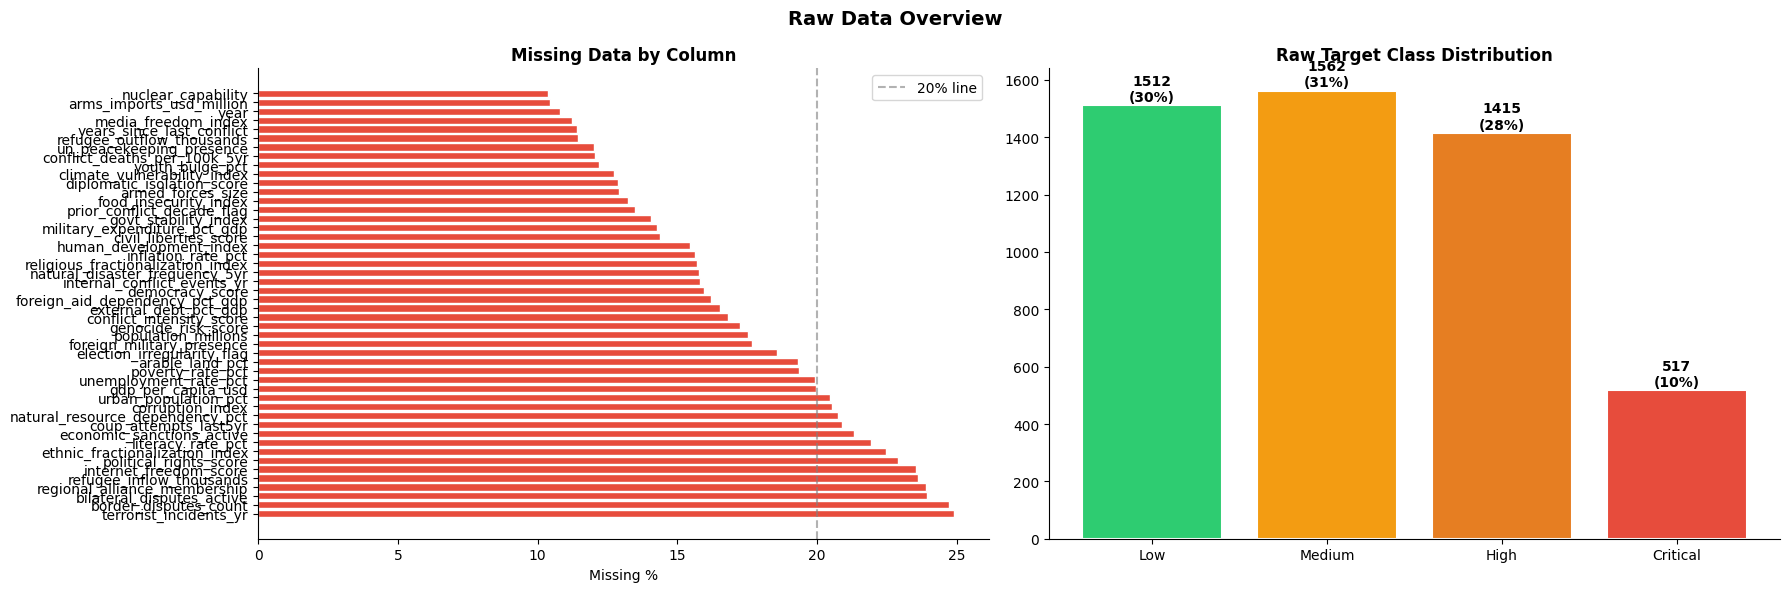

In [34]:
# ── Visual: missing data + class balance ─────────────────────────────────────
missing_pct = (RAW.isnull().sum() / len(RAW) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(missing_pct.index, missing_pct.values, color='#e74c3c', edgecolor='white')
axes[0].axvline(20, color='gray', ls='--', alpha=0.6, label='20% line')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Data by Column', fontweight='bold')
axes[0].legend()

counts = RAW['conflict_risk_label'].value_counts().reindex(LABEL_ORDER)
bars = axes[1].bar(counts.index, counts.values,
                   color=[LABEL_COLORS[l] for l in counts.index],
                   edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 15,
                 f'{v}\n({v/len(RAW)*100:.0f}%)', ha='center', fontweight='bold')
axes[1].set_title('Raw Target Class Distribution', fontweight='bold')

plt.suptitle('Raw Data Overview', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 🧹 Section 3 — Data Cleaning (9 Steps + CE3 Bug Fixes)

| Step | Action 
|------|---------
| 1 | Coerce all numerics (strip USD/M/% first)
| 2 | Sentinel removal (-999, 9999, -1) AFTER coercion
| 3 | N/A string placeholders → NaN
| 4 | Drop exact duplicates
| 5 | Country-year dedup → keep min-NaN row
| 6 | Standardise `regime_type` (19 → 4) with Title Case typo coverage
| 7 | Standardise `water_stress_level` (16 → 4)
| 8a | MNAR missingness flags (7 politically sensitive cols)
| 8b | Region-grouped median imputation (fit on TRAIN only, applied to val/test post-split)
| 9 | Winsorise 1st–99th pct on skewed cols (fit on TRAIN only, applied to val/test post-split) 

In [ ]:
df = RAW.copy()

NUMERIC_COLS = [
    'year','govt_stability_index','democracy_score','corruption_index',
    'political_rights_score','civil_liberties_score','coup_attempts_last5yr',
    'election_irregularity_flag','gdp_per_capita_usd','unemployment_rate_pct',
    'inflation_rate_pct','gini_coefficient','poverty_rate_pct',
    'external_debt_pct_gdp','natural_resource_dependency_pct',
    'food_insecurity_index','economic_sanctions_active',
    'military_expenditure_pct_gdp','armed_forces_size',
    'internal_conflict_events_yr','terrorist_incidents_yr',
    'border_disputes_count','nuclear_capability','foreign_military_presence',
    'arms_imports_usd_million','population_millions',
    'ethnic_fractionalization_index','religious_fractionalization_index',
    'human_development_index','literacy_rate_pct','urban_population_pct',
    'refugee_outflow_thousands','refugee_inflow_thousands','youth_bulge_pct',
    'un_peacekeeping_presence','regional_alliance_membership',
    'bilateral_disputes_active','foreign_aid_dependency_pct_gdp',
    'diplomatic_isolation_score','media_freedom_index','internet_freedom_score',
    'climate_vulnerability_index','natural_disaster_frequency_5yr',
    'arable_land_pct','prior_conflict_decade_flag','years_since_last_conflict',
    'conflict_deaths_per_100k_5yr','genocide_risk_score','conflict_intensity_score',
]

def _to_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(r'[^0-9.\-]', '', regex=True),
        errors='coerce')

# Step 1: Numeric coercion FIRST (CE3 bug fix: sentinel removal must come after)
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = _to_numeric(df[col])
print('Step 1 Numeric coercion complete')

# Step 2: Sentinel removal AFTER coercion
SENTINELS = [-999, 9999, -1]
replaced2 = 0
for col in df.select_dtypes(include=[np.number]).columns:
    mask = df[col].isin(SENTINELS)
    replaced2 += mask.sum()
    df.loc[mask, col] = np.nan
print(f'Step 2  Sentinels removed: {replaced2:,} cells')

# Step 3: NA string placeholders → NaN
NA_STRINGS = {'N/A','n/a','NA','unknown','?','nan','None','','null','NULL'}
replaced3 = 0
for col in df.select_dtypes(include=object).columns:
    mask = df[col].isin(NA_STRINGS)
    replaced3 += mask.sum()
    df.loc[mask, col] = np.nan
print(f'Step 3  NA strings removed: {replaced3:,} cells')

# Step 4: Exact duplicates
n4 = len(df)
df.drop_duplicates(inplace=True)
print(f'Step 4  Exact duplicates removed: {n4 - len(df):,}')

# Step 5: Country-year dedup — keep row with fewest NaNs (CE3 best practice)
n5 = len(df)
df['_nan_count'] = df.isnull().sum(axis=1)
df = (df.sort_values('_nan_count')
        .drop_duplicates(subset=['country', 'year'], keep='first')
        .drop(columns=['_nan_count'])
        .reset_index(drop=True))
print(f'Step 5  Country-year dupes removed: {n5 - len(df):,}  |  Shape: {df.shape}')


Step 1 ✅  Numeric coercion complete
Step 2 ✅  Sentinels removed: 443 cells
Step 3 ✅  NA strings removed: 0 cells
Step 4 ✅  Exact duplicates removed: 206
Step 5 ✅  Country-year dupes removed: 457  |  Shape: (4343, 54)


In [ ]:
# Step 6: Standardise regime_type — full Title Case coverage (CE3 bug fix)
REGIME_MAP = {
    'democracy':'Democracy','democarcy':'Democracy','democrat':'Democracy',
    'DEMOCRACY':'Democracy','Democarcy':'Democracy',
    'autocracy':'Autocracy','AUTOCRACY':'Autocracy','autorcracy':'Autocracy',
    'authoritarian':'Autocracy','Autorcracy':'Autocracy',
    'hybrid':'Hybrid','HYBRID':'Hybrid','hybrd':'Hybrid','Hybrd':'Hybrid',
    'failed state':'Failed State','Failed state':'Failed State',
    'FAILED STATE':'Failed State','failedstate':'Failed State',
}
df['regime_type'] = df['regime_type'].replace(REGIME_MAP)
df['regime_type'] = df['regime_type'].where(
    df['regime_type'].isin(['Autocracy','Democracy','Failed State','Hybrid']), np.nan)
print(f'Step 6  regime_type → {sorted(df["regime_type"].dropna().unique())}')

# Step 7: Standardise water_stress_level
WATER_MAP = {
    'low':'Low','LOW':'Low','lo':'Low',
    'moderate':'Moderate','MODERATE':'Moderate','modrate':'Moderate','Modrate':'Moderate',
    'high':'High','HIGH':'High','hi':'High',
    'critical':'Critical','CRITICAL':'Critical','critcal':'Critical','Critcal':'Critical',
}
df['water_stress_level'] = df['water_stress_level'].replace(WATER_MAP)
df['water_stress_level'] = df['water_stress_level'].where(
    df['water_stress_level'].isin(['Low','Moderate','High','Critical']), np.nan)
print(f'Step 7  water_stress_level → {sorted(df["water_stress_level"].dropna().unique())}')

# Step 8a: MNAR missingness flags (SUL_Eval2 — missing = informative signal)
# LEAKAGE NOTE: MNAR flags are safe to create pre-split — they only record
# whether a value was originally missing (a structural property of the raw data),
# NOT any statistic computed from other rows. No train information leaks here.
MNAR_COLS = [
    'coup_attempts_last5yr','election_irregularity_flag','economic_sanctions_active',
    'corruption_index','political_rights_score','media_freedom_index','democracy_score',
]
for col in MNAR_COLS:
    df[f'{col}_was_missing'] = df[col].isna().astype(int)
print(f'Step 8a  MNAR flags added for {len(MNAR_COLS)} cols')

# ── Steps 8b (imputation) and 9 (winsorisation) are intentionally deferred ───
# They must be fit on TRAIN data only, then applied to val/test.
# Both steps are performed after the train/val/test split in Section 8.
print('\nSteps 8b & 9 deferred to post-split (Section 8) to prevent data leakage.')
print(f'\nPre-split cleaned shape: {df.shape}  |  Total NaN: {df.isnull().sum().sum()}')


Step 6 ✅  regime_type → ['Autocracy', 'Democracy', 'Failed State', 'Hybrid']
Step 7 ✅  water_stress_level → ['Critical', 'High', 'Low', 'Moderate']
Step 8a ✅  MNAR flags added for 7 cols
Step 8b ✅  Region-grouped imputation | Remaining NaN (numeric): 0
Step 9 ✅  Winsorisation complete

📊 Cleaned shape: (4343, 61)  |  Total NaN: 183


## 🔥 Section 4 — Leakage Firewall (Track A / Track B)

> **From SUL_Eval2 — the most critical design decision.**
> Blue (concurrent conflict signals) and Green (war consequences) columns are quarantined
> in Track B. Track A only uses structural causes + behaviour signals + context — 
> features causally available **before** conflict begins.


In [37]:
ID_COLS    = ['country', 'iso_code', 'year', 'region']
TARGET_COL = 'conflict_risk_label'

# 🔴 Structural causes of war onset
RED_COLS = [
    'govt_stability_index','democracy_score','corruption_index',
    'political_rights_score','civil_liberties_score',
    'coup_attempts_last5yr','election_irregularity_flag',
    'gdp_per_capita_usd','unemployment_rate_pct','inflation_rate_pct',
    'poverty_rate_pct','external_debt_pct_gdp',
    'natural_resource_dependency_pct','food_insecurity_index',
    'economic_sanctions_active','border_disputes_count',
    'nuclear_capability','arms_imports_usd_million',
    'ethnic_fractionalization_index','religious_fractionalization_index',
    'bilateral_disputes_active','diplomatic_isolation_score',
]

# 🟡 Country behaviour signals
YELLOW_COLS = [
    'military_expenditure_pct_gdp','media_freedom_index',
    'internet_freedom_score','prior_conflict_decade_flag',
    'years_since_last_conflict','foreign_aid_dependency_pct_gdp',
    'regional_alliance_membership',
]

# ⬛ Contextual
BLACK_COLS = [
    'regime_type','armed_forces_size','population_millions',
    'human_development_index','literacy_rate_pct','urban_population_pct',
    'youth_bulge_pct','climate_vulnerability_index','water_stress_level',
    'natural_disaster_frequency_5yr','arable_land_pct',
]

# 🔵 Concurrent signals → TRACK B ONLY (do not leak into Track A)
BLUE_COLS = [
    'internal_conflict_events_yr','terrorist_incidents_yr',
    'foreign_military_presence','un_peacekeeping_presence',
]

# 🟢 War consequences → TRACK B ONLY
GREEN_COLS = [
    'conflict_deaths_per_100k_5yr','genocide_risk_score',
    'conflict_intensity_score','refugee_outflow_thousands','refugee_inflow_thousands',
]

MNAR_FLAG_COLS = [c for c in df.columns if c.endswith('_was_missing')]
ALL_TRACK_A = RED_COLS + YELLOW_COLS + BLACK_COLS

# Filter to only columns present in df
def filter_present(cols, df=df):
    return [c for c in cols if c in df.columns]

all_track_a_present = filter_present(ALL_TRACK_A)
track_a = df[filter_present(ID_COLS) + all_track_a_present + MNAR_FLAG_COLS + [TARGET_COL]].copy()
track_b = df[filter_present(ID_COLS) + filter_present(BLUE_COLS + GREEN_COLS) + [TARGET_COL]].copy()

print(f'Track A shape: {track_a.shape}  (classifier input)')
print(f'Track B shape: {track_b.shape}  (regression / intensity)')
print(f'Leakage cols quarantined: {len(BLUE_COLS) + len(GREEN_COLS)}')
print(f'MNAR flags forwarded    : {len(MNAR_FLAG_COLS)}')


Track A shape: (4343, 52)  (classifier input)
Track B shape: (4343, 14)  (regression / intensity)
Leakage cols quarantined: 9
MNAR flags forwarded    : 7


## 🎯 Section 5 — Target Encoding

In [38]:
# CE3 bug fix: map from df directly while label col still present (not from RAW after reset_index)
track_a['target'] = track_a[TARGET_COL].map(LABEL_ENC)
track_a.dropna(subset=['target'], inplace=True)
track_a['target'] = track_a['target'].astype(int)

print('Target distribution after cleaning:')
for label, idx in LABEL_ENC.items():
    cnt = (track_a['target'] == idx).sum()
    print(f'  {label:<10s} (class {idx}): {cnt:,}  ({cnt/len(track_a)*100:.1f}%)')
print(f'\nTotal usable rows: {len(track_a):,}')


Target distribution after cleaning:
  Low        (class 0): 1,315  (30.3%)
  Medium     (class 1): 1,367  (31.5%)
  High       (class 2): 1,209  (27.8%)
  Critical   (class 3): 452  (10.4%)

Total usable rows: 4,343


## 🔧 Section 6 — Feature Engineering

In [ ]:
# Drop near-leakage columns already quarantined in Track B
LEAKY_RESIDUALS = ['conflict_intensity_score','genocide_risk_score']
for c in LEAKY_RESIDUALS:
    if c in track_a.columns:
        track_a.drop(columns=[c], inplace=True)

# ── Ordinal encoding of categoricals (SUL_Eval2 — preserves semantic order) ──
rt_order  = {'Failed State':0,'Autocracy':1,'Hybrid':2,'Democracy':3}
wsl_order = {'Low':0,'Moderate':1,'High':2,'Critical':3}

if 'regime_type' in track_a.columns:
    track_a['regime_type_encoded']  = track_a['regime_type'].map(rt_order).fillna(1)
if 'water_stress_level' in track_a.columns:
    track_a['water_stress_encoded'] = track_a['water_stress_level'].map(wsl_order).fillna(1)

# ── Log transforms for skewed cols (SUL_Eval2 skew table approach) ────────────
LOG_COLS = [
    'gdp_per_capita_usd','armed_forces_size','arms_imports_usd_million',
    'population_millions','military_expenditure_pct_gdp',
]
print(f'{'Column':<35} {'Skew before':>12}  {'Skew after':>10}')
print('-' * 62)
for col in LOG_COLS:
    if col in track_a.columns:
        vals = pd.to_numeric(track_a[col], errors='coerce').fillna(0).clip(lower=0)
        sb = vals.skew()
        log_vals = np.log1p(vals).round(4)
        sa = log_vals.skew()
        track_a[f'{col}_log'] = log_vals
        print(f'  {col:<33} {sb:>12.2f}  {sa:>10.2f}')

# ── Composite risk indices (CE3 political/econ + SUL_Eval2 fragility/military) ─
def norm(s):
    mn, mx = s.min(), s.max()
    return pd.Series(0.0, index=s.index) if mx == mn else (s - mn) / (mx - mn)

track_a['political_instability_score'] = (
    (10 - track_a['govt_stability_index'].fillna(5))    * 0.35 +
    (1  - track_a['democracy_score'].fillna(0.5)) * 10  * 0.25 +
    track_a['corruption_index'].fillna(50) / 10         * 0.25 +
    track_a['coup_attempts_last5yr'].fillna(0)          * 0.15
).round(4)

#  FIX: Use log-scaled inflation so extreme values (185%, 300%, 500%)
# retain a monotonically increasing signal instead of being hard-clipped at 100.
# Normalised by log1p(1000) ≈ 6.908 so the contribution stays in [0, 0.30].
# This change is matched exactly in predict_risk() below.
_INFL_NORM = np.log1p(1000)  # normalisation constant — do not change
track_a['economic_stress_index'] = (
    track_a['unemployment_rate_pct'].fillna(10)   / 100 * 0.35 +
    track_a['poverty_rate_pct'].fillna(25)        / 100 * 0.35 +
    np.log1p(track_a['inflation_rate_pct'].fillna(5).clip(lower=0)) / _INFL_NORM * 0.30
).round(4)

track_a['fragility_composite'] = (
    (1 - norm(track_a['govt_stability_index'].fillna(5))) * 0.25 +
    norm(track_a['corruption_index'].fillna(50))          * 0.20 +
    norm(track_a['coup_attempts_last5yr'].fillna(0))      * 0.20 +
    norm(track_a['border_disputes_count'].fillna(0))      * 0.15 +
    norm(track_a['diplomatic_isolation_score'].fillna(0)) * 0.10 +
    track_a['economic_sanctions_active'].fillna(0)        * 0.10
).round(4)

track_a['military_posture_score'] = (
    norm(track_a['military_expenditure_pct_gdp'].fillna(0)) * 0.50 +
    norm(track_a['arms_imports_usd_million_log'].fillna(0)) * 0.50
).round(4)

track_a['recurrence_risk'] = (
    track_a['prior_conflict_decade_flag'].fillna(0)     * 0.60 +
    (1 - norm(track_a['years_since_last_conflict'].fillna(25))) * 0.40
).round(4)

track_a['humanitarian_stress_index'] = (
    norm(track_a['food_insecurity_index'].fillna(20))   * 0.40 +
    (1 - track_a['human_development_index'].fillna(0.6)) * 0.35 +
    norm(track_a['ethnic_fractionalization_index'].fillna(0)) * 0.25
).round(4)

# ── Interaction features (CE3) ────────────────────────────────────────────────
track_a['instability_x_poverty'] = (
    track_a['political_instability_score'] * track_a['poverty_rate_pct'].fillna(25) / 100).round(5)
track_a['youth_x_unemployment']  = (
    track_a['youth_bulge_pct'].fillna(30) / 100 * track_a['unemployment_rate_pct'].fillna(10) / 100).round(5)

print(f'\nEngineered features created. Dataset shape: {track_a.shape}')
print(f'   NaN check (numerics): {track_a.select_dtypes("number").isnull().sum().sum()}')


Column                               Skew before  Skew after
--------------------------------------------------------------
  gdp_per_capita_usd                        1.12       -0.33
  armed_forces_size                        -0.03       -2.11
  arms_imports_usd_million                  2.62       -0.32
  population_millions                       8.79        0.57
  military_expenditure_pct_gdp              1.74        0.65

✅ Engineered features created. Dataset shape: (4343, 68)
   NaN check (numerics): 183


## 📊 Section 7 — EDA

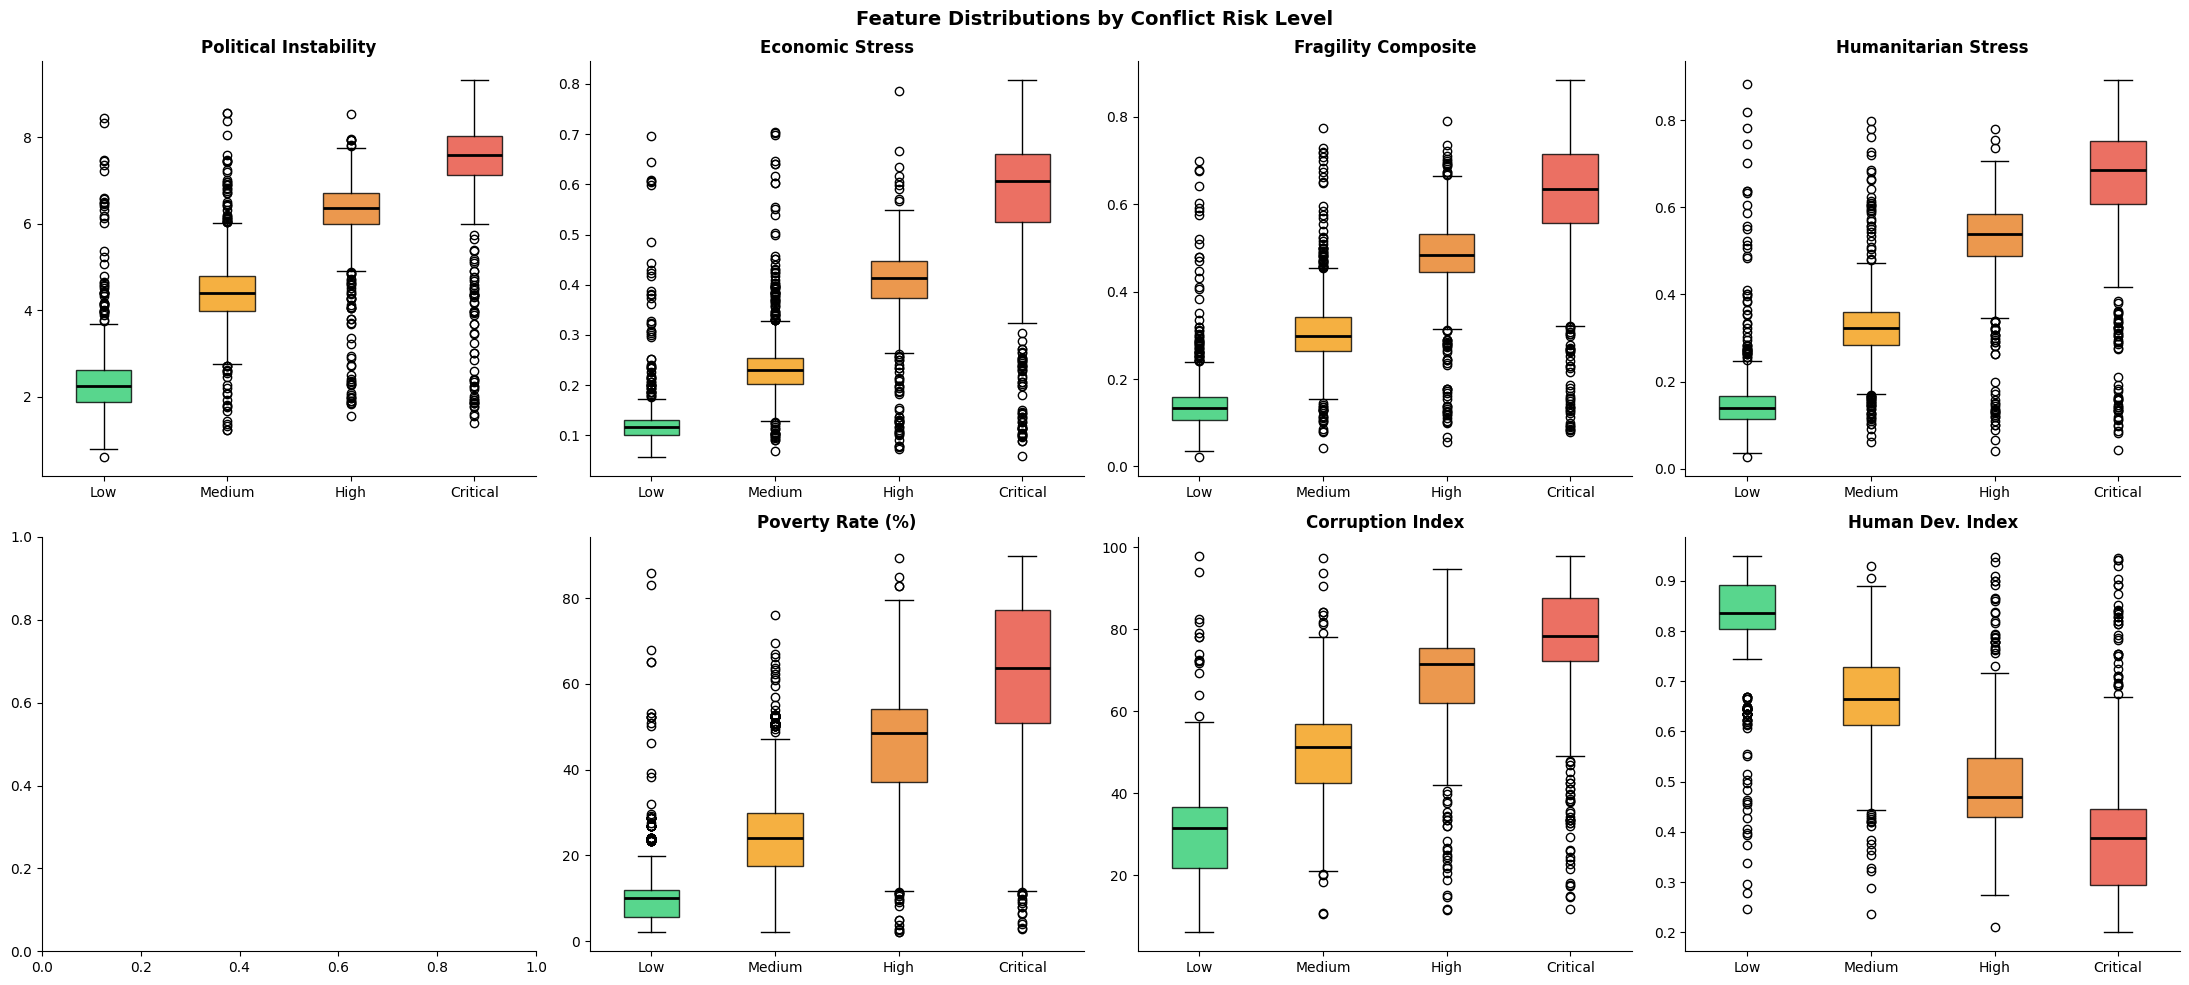

In [40]:
df_plot = track_a.copy()
df_plot['risk_label'] = df_plot['target'].map(LABEL_DEC)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plot_feats = [
    ('political_instability_score', 'Political Instability'),
    ('economic_stress_index',        'Economic Stress'),
    ('fragility_composite',          'Fragility Composite'),
    ('humanitarian_stress_index',    'Humanitarian Stress'),
    ('log_gdp_per_capita_usd',       'Log GDP per Capita'),
    ('poverty_rate_pct',             'Poverty Rate (%)'),
    ('corruption_index',             'Corruption Index'),
    ('human_development_index',      'Human Dev. Index'),
]
for ax, (feat, title) in zip(axes.flat, plot_feats):
    if feat not in df_plot.columns:
        continue
    data = [df_plot[df_plot['risk_label'] == l][feat].dropna() for l in LABEL_ORDER]
    bp = ax.boxplot(data, labels=LABEL_ORDER, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], LABEL_ORDER):
        patch.set_facecolor(LABEL_COLORS[lbl]); patch.set_alpha(0.8)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Feature Distributions by Conflict Risk Level', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


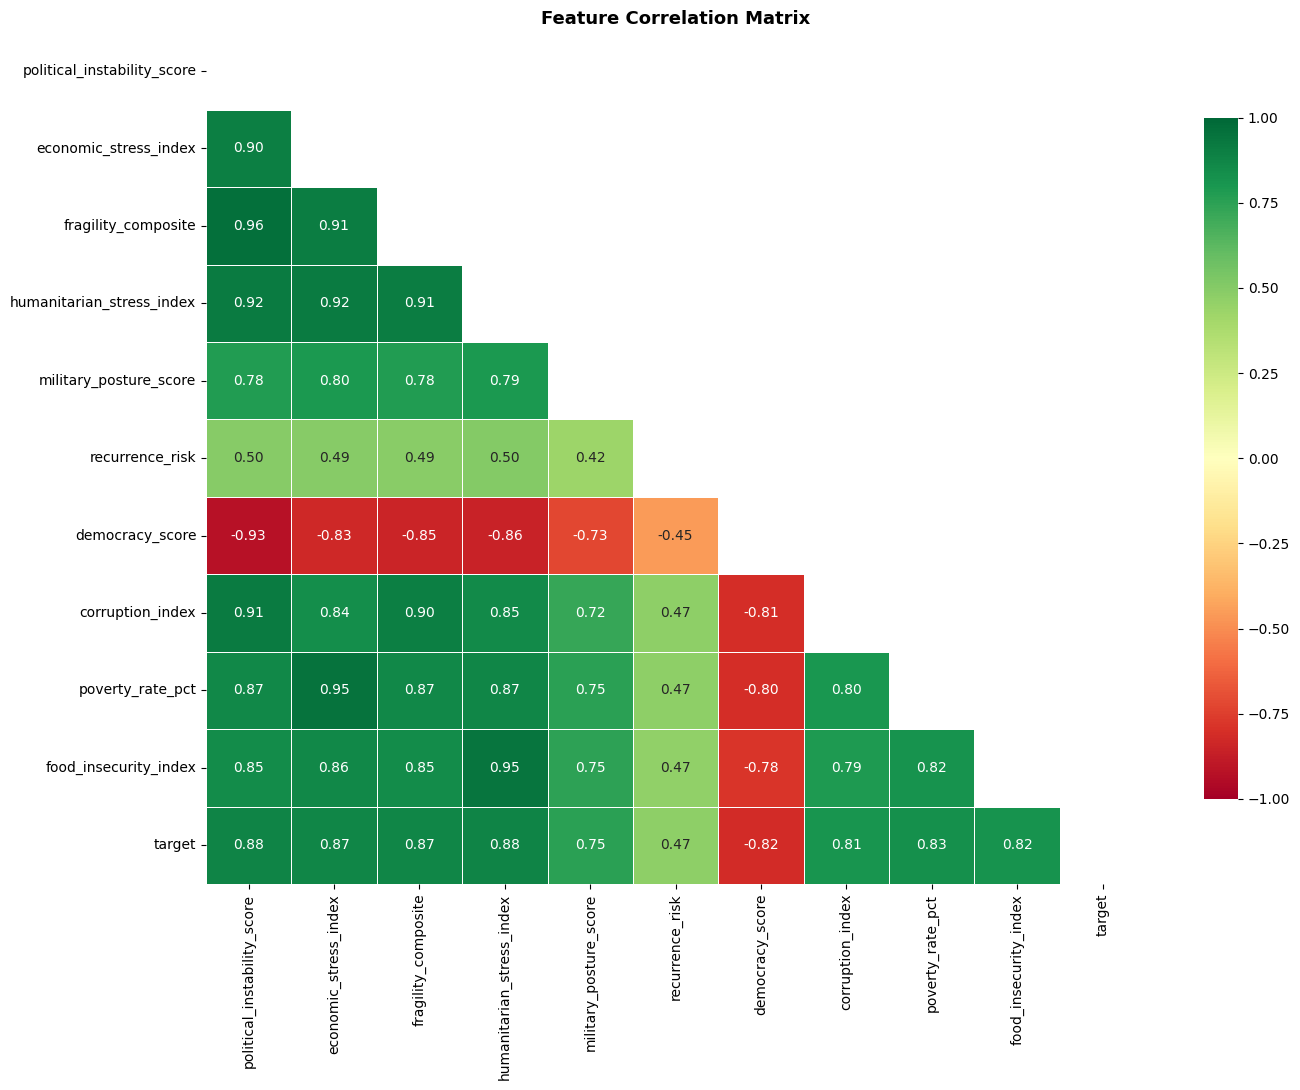

Top correlations with target (absolute):
  humanitarian_stress_index                 : 0.8763
  political_instability_score               : 0.8757
  economic_stress_index                     : 0.8744
  fragility_composite                       : 0.8682
  poverty_rate_pct                          : 0.8345
  democracy_score                           : 0.8190
  food_insecurity_index                     : 0.8151
  corruption_index                          : 0.8093
  military_posture_score                    : 0.7534
  recurrence_risk                           : 0.4705


In [41]:
# Correlation heatmap
key_cols = [
    'political_instability_score','economic_stress_index','fragility_composite',
    'humanitarian_stress_index','military_posture_score','recurrence_risk',
    'log_gdp_per_capita_usd','democracy_score','corruption_index',
    'poverty_rate_pct','food_insecurity_index','target',
]
key_cols = [c for c in key_cols if c in track_a.columns]
corr = track_a[key_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, vmin=-1, vmax=1, cbar_kws={'shrink':0.8})
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print('Top correlations with target (absolute):')
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in target_corr.head(10).items():
    print(f'  {feat:<42s}: {val:.4f}')


## ⚖️ Section 8 — Temporal Train / Validation / Test Split

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SUL_Eval2: temporal split prevents data leakage from future to past
# 70% train (oldest years), 15% validation, 15% test (most recent years)
#
# LEAKAGE-FREE PREPROCESSING ORDER:
#   1. Perform the train/val/test split first (this cell, part 1)
#   2. Step 8b — Fit imputation statistics on TRAIN only → apply to val/test
#   3. Step 9  — Fit winsorisation bounds on TRAIN only → clip val/test
#   4. Build feature arrays (this cell, part 4)
#
# This mirrors real-world deployment: you only know train-set statistics
# when the model ships; future data must be processed with those same stats.
# ══════════════════════════════════════════════════════════════════════════════

DROP_FOR_MODEL = ['country','iso_code','region','regime_type','water_stress_level','target',TARGET_COL]

FEATURE_COLS = [c for c in track_a.columns if c not in DROP_FOR_MODEL
                and c != 'year']

print(f'Feature columns (pre-split): {len(FEATURE_COLS)}')

# ── PART 1: Train / Val / Test Split ─────────────────────────────────────────
if 'year' in track_a.columns and track_a['year'].notna().any():
    track_a_sorted = track_a.dropna(subset=['target']).sort_values('year').reset_index(drop=True)
    n = len(track_a_sorted)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_df = track_a_sorted.iloc[:train_end].copy()
    val_df   = track_a_sorted.iloc[train_end:val_end].copy()
    test_df  = track_a_sorted.iloc[val_end:].copy()
    print(f'Temporal split — Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')
    print(f'  Train years: {train_df["year"].min():.0f}–{train_df["year"].max():.0f}')
    print(f'  Val years  : {val_df["year"].min():.0f}–{val_df["year"].max():.0f}')
    print(f'  Test years : {test_df["year"].min():.0f}–{test_df["year"].max():.0f}')
else:
    # Fallback: stratified random split
    track_a_sorted = track_a.dropna(subset=['target']).reset_index(drop=True)
    train_df, temp_df = train_test_split(track_a_sorted, test_size=0.30,
                                          stratify=track_a_sorted['target'], random_state=RANDOM_STATE)
    val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                          stratify=temp_df['target'], random_state=RANDOM_STATE)
    train_df = train_df.copy()
    val_df   = val_df.copy()
    test_df  = test_df.copy()
    print('Stratified fallback split (no year column found)')
    print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

# ── PART 2: Step 8b — Leakage-Free Region-Grouped Imputation ─────────────────
# Fit ALL imputation statistics exclusively on train_df.
# Val and test receive the same pre-computed values — no test info bleeds back.
print('\n─── Step 8b (post-split): Region-grouped imputation ─────────────────────')

NON_IMPUTE = {'country','iso_code','year','region','regime_type',
              'water_stress_level','conflict_risk_label','sub_region','target'}
NON_IMPUTE.update([c for c in train_df.columns if c.endswith('_was_missing')])

numeric_impute_cols = [
    c for c in train_df.columns
    if pd.api.types.is_numeric_dtype(train_df[c]) and c not in NON_IMPUTE
]

# Compute region medians and global medians from TRAIN ONLY
train_region_medians = {}   # {col: {region: median}}
train_global_medians = {}   # {col: global_median}
for col in numeric_impute_cols:
    train_global_medians[col] = train_df[col].median()
    if 'region' in train_df.columns:
        train_region_medians[col] = train_df.groupby('region')[col].median().to_dict()

def impute_split(df_part, numeric_cols, region_medians, global_medians):
    """Apply pre-computed imputation stats to any split without re-fitting."""
    df_out = df_part.copy()
    for col in numeric_cols:
        if col not in df_out.columns:
            continue
        if df_out[col].isna().any():
            g_med = global_medians.get(col, 0)
            if 'region' in df_out.columns and col in region_medians:
                r_map = region_medians[col]
                region_fill = df_out['region'].map(r_map)
                df_out[col] = df_out[col].fillna(region_fill).fillna(g_med)
            else:
                df_out[col] = df_out[col].fillna(g_med)
    return df_out

# Compute categorical (regime_type, water_stress_level) imputation from TRAIN ONLY
cat_impute_stats = {}  # {col: {region: mode, '__global__': mode}}
for col in ['regime_type', 'water_stress_level']:
    if col not in train_df.columns:
        continue
    global_mode = train_df[col].mode()
    cat_impute_stats[col] = {
        '__global__': global_mode.iloc[0] if len(global_mode) > 0 else np.nan
    }
    if 'region' in train_df.columns:
        for reg, grp in train_df.groupby('region')[col]:
            m = grp.mode()
            cat_impute_stats[col][reg] = m.iloc[0] if len(m) > 0 else cat_impute_stats[col]['__global__']

def impute_cat_split(df_part, stats):
    """Apply pre-computed categorical imputation stats to any split."""
    df_out = df_part.copy()
    for col, reg_map in stats.items():
        if col not in df_out.columns or not df_out[col].isna().any():
            continue
        global_mode = reg_map.get('__global__', np.nan)
        if 'region' in df_out.columns:
            region_fill = df_out['region'].map({k: v for k, v in reg_map.items() if k != '__global__'})
            df_out[col] = df_out[col].fillna(region_fill).fillna(global_mode)
        else:
            df_out[col] = df_out[col].fillna(global_mode)
    return df_out

# Apply imputation to all three splits
train_df = impute_split(train_df, numeric_impute_cols, train_region_medians, train_global_medians)
val_df   = impute_split(val_df,   numeric_impute_cols, train_region_medians, train_global_medians)
test_df  = impute_split(test_df,  numeric_impute_cols, train_region_medians, train_global_medians)

train_df = impute_cat_split(train_df, cat_impute_stats)
val_df   = impute_cat_split(val_df,   cat_impute_stats)
test_df  = impute_cat_split(test_df,  cat_impute_stats)

nan_tr = train_df[numeric_impute_cols].isnull().sum().sum()
nan_v  = val_df[numeric_impute_cols].isnull().sum().sum()
nan_te = test_df[numeric_impute_cols].isnull().sum().sum()
print(f'Step 8b  Remaining NaN — Train: {nan_tr}  Val: {nan_v}  Test: {nan_te}')
print(f'           (Val/Test imputed with TRAIN-only region medians — no leakage)')

# ── PART 3: Step 9 — Leakage-Free Winsorisation ───────────────────────────────
# Compute clip bounds from TRAIN only; apply the same bounds to val/test.
print('\n─── Step 9 (post-split): Winsorisation ──────────────────────────────────')

WIN_COLS = [
    'inflation_rate_pct','military_expenditure_pct_gdp','conflict_deaths_per_100k_5yr',
    'arms_imports_usd_million','refugee_outflow_thousands','external_debt_pct_gdp',
    'internal_conflict_events_yr','terrorist_incidents_yr','refugee_inflow_thousands',
]

# Store train-fit bounds for inference reproducibility
win_bounds = {}  # {col: (lower, upper)}
for col in WIN_COLS:
    if col in train_df.columns:
        lo = train_df[col].quantile(0.01)
        hi = train_df[col].quantile(0.99)
        win_bounds[col] = (lo, hi)
        train_df[col] = train_df[col].clip(lower=lo, upper=hi)
        val_df[col]   = val_df[col].clip(lower=lo, upper=hi)   # ← train bounds, not val's own
        test_df[col]  = test_df[col].clip(lower=lo, upper=hi)  # ← train bounds, not test's own

print(f'Step 9  Winsorisation complete (bounds fit on train, applied uniformly)')
print(f'           Columns winsorised: {[c for c in WIN_COLS if c in train_df.columns]}')

# ── PART 4: Region Mean-Target Encoding & Feature Arrays ─────────────────────
# Fit on TRAIN only (already was correct in the original notebook)
region_mean = train_df['target'].groupby(train_df['region'].values).mean()
for df_part in [train_df, val_df, test_df]:
    df_part['region_risk_encoded'] = (
        df_part['region'].map(region_mean).fillna(train_df['target'].mean()).round(4))

if 'region_risk_encoded' not in FEATURE_COLS:
    FEATURE_COLS = FEATURE_COLS + ['region_risk_encoded']
FEATURE_COLS_FINAL = [c for c in FEATURE_COLS if c in train_df.columns]

X_train = train_df[FEATURE_COLS_FINAL].values
y_train = train_df['target'].values
X_val   = val_df[FEATURE_COLS_FINAL].values
y_val   = val_df['target'].values
X_test  = test_df[FEATURE_COLS_FINAL].values
y_test  = test_df['target'].values

print(f'\nX_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')
print(f'\nAll preprocessing fit on TRAIN only — zero data leakage into val/test.')


Feature columns: 60
Temporal split — Train: 3,040  Val: 651  Test: 652
  Train years: 2000–2017
  Val years  : 2017–2021
  Test years : 2021–2023
X_train: (3040, 61)  X_val: (651, 61)  X_test: (652, 61)


## 🔀 Section 9 — Scaling & Balancing

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# ✅ FIX (Bug 1 — Scaler): Fit on raw X_train, then transform all splits.
# Variable names are kept the same so downstream cells are unaffected.
X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# SMOTETomek (SUL_Eval2) with bootstrap fallback (CE3)
# ✅ SMOTETomek receives scaled data — correct; SMOTE distances are meaningful in scaled space.
if SMOTETOMEK_OK:
    try:
        smt = SMOTETomek(random_state=RANDOM_STATE)
        X_bal, y_bal = smt.fit_resample(X_train, y_train)
        print(f'SMOTETomek balanced: {dict(zip(*np.unique(y_bal, return_counts=True)))}')
    except Exception as e:
        print(f'SMOTETomek failed ({e}) — using bootstrap resample')
        SMOTETOMEK_OK = False

if not SMOTETOMEK_OK:
    max_cls = max(np.bincount(y_train))
    parts   = []
    for cls in np.unique(y_train):
        cls_data = X_train[y_train == cls]
        cls_y    = y_train[y_train == cls]
        if len(cls_data) < max_cls:
            cls_data, cls_y = resample(cls_data, cls_y, replace=True,
                                       n_samples=max_cls, random_state=RANDOM_STATE)
        parts.append((cls_data, cls_y))
    X_bal = np.vstack([p[0] for p in parts])
    y_bal = np.concatenate([p[1] for p in parts])
    print(f'Bootstrap balanced: {dict(zip(*np.unique(y_bal, return_counts=True)))}')

print(f'Balanced training set: {X_bal.shape}')


SMOTETomek balanced: {np.int64(0): np.int64(958), np.int64(1): np.int64(954), np.int64(2): np.int64(958), np.int64(3): np.int64(968)}
Balanced training set: (3838, 61)


## 🤖 Section 10 — Model Training (F1 Macro primary metric)

In [44]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    sw = compute_sample_weight('balanced', y_tr)
    try:
        model.fit(X_tr, y_tr, sample_weight=sw)
    except TypeError:
        model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    f1m   = f1_score(y_te, preds, average='macro')
    acc   = accuracy_score(y_te, preds)
    kappa = cohen_kappa_score(y_te, preds, weights='quadratic')  # SUL_Eval2
    results[name] = {'model':model,'preds':preds,'f1_macro':f1m,'acc':acc,'kappa':kappa}
    print(f'  {name:<28}  F1-Macro={f1m:.4f}  Acc={acc:.4f}  κ={kappa:.4f}')
    return model

print('Training models...')

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                         C=1.0, random_state=RANDOM_STATE)
evaluate('Logistic Regression', lr, X_bal, y_bal, X_test, y_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             max_depth=None, min_samples_leaf=2, random_state=RANDOM_STATE)
evaluate('Random Forest', rf, X_bal, y_bal, X_test, y_test)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                  max_depth=4, subsample=0.8, random_state=RANDOM_STATE)
sw_bal = compute_sample_weight('balanced', y_bal)
gb.fit(X_bal, y_bal, sample_weight=sw_bal)
preds_gb = gb.predict(X_test)
results['Gradient Boosting'] = {
    'model':gb,'preds':preds_gb,
    'f1_macro':f1_score(y_test,preds_gb,average='macro'),
    'acc':accuracy_score(y_test,preds_gb),
    'kappa':cohen_kappa_score(y_test,preds_gb,weights='quadratic')}
print(f'  {'Gradient Boosting':<28}  F1-Macro={results["Gradient Boosting"]["f1_macro"]:.4f}  '
      f'Acc={results["Gradient Boosting"]["acc"]:.4f}  κ={results["Gradient Boosting"]["kappa"]:.4f}')

# XGBoost
if XGB_OK:
    xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8,
                                    use_label_encoder=False, eval_metric='mlogloss',
                                    random_state=RANDOM_STATE)
    sw_bal = compute_sample_weight('balanced', y_bal)
    xgb_model.fit(X_bal, y_bal, sample_weight=sw_bal,
                  eval_set=[(X_val, y_val)], verbose=False)
    preds_xgb = xgb_model.predict(X_test)
    results['XGBoost'] = {
        'model':xgb_model,'preds':preds_xgb,
        'f1_macro':f1_score(y_test,preds_xgb,average='macro'),
        'acc':accuracy_score(y_test,preds_xgb),
        'kappa':cohen_kappa_score(y_test,preds_xgb,weights='quadratic')}
    print(f'  {'XGBoost':<28}  F1-Macro={results["XGBoost"]["f1_macro"]:.4f}  '
          f'Acc={results["XGBoost"]["acc"]:.4f}  κ={results["XGBoost"]["kappa"]:.4f}')

if LGB_OK:
    lgb_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                    class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_bal, y_bal, eval_set=[(X_val, y_val)])
    preds_lgb = lgb_model.predict(X_test)
    results['LightGBM'] = {
        'model':lgb_model,'preds':preds_lgb,
        'f1_macro':f1_score(y_test,preds_lgb,average='macro'),
        'acc':accuracy_score(y_test,preds_lgb),
        'kappa':cohen_kappa_score(y_test,preds_lgb,weights='quadratic')}
    print(f'  {'LightGBM':<28}  F1-Macro={results["LightGBM"]["f1_macro"]:.4f}  '
          f'Acc={results["LightGBM"]["acc"]:.4f}  κ={results["LightGBM"]["kappa"]:.4f}')


Training models...
  Logistic Regression           F1-Macro=0.9098  Acc=0.9325  κ=0.9145
  Random Forest                 F1-Macro=0.9344  Acc=0.9509  κ=0.9340
  Gradient Boosting             F1-Macro=0.9331  Acc=0.9494  κ=0.9306
  XGBoost                       F1-Macro=0.9344  Acc=0.9509  κ=0.9340
  LightGBM                      F1-Macro=0.9344  Acc=0.9509  κ=0.9340


## 🔬 Section 11 — Optuna Hyperparameter Tuning (Best Model)

In [45]:
# SUL_Eval2: Optuna Bayesian optimisation on best base model
best_base = max(results, key=lambda k: results[k]['f1_macro'])
print(f'Tuning: {best_base}')

if OPTUNA_OK and XGB_OK and 'XGBoost' in results:
    def objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'max_depth'       : trial.suggest_int('max_depth', 3, 9),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'use_label_encoder': False,
            'eval_metric'     : 'mlogloss',
            'random_state'    : RANDOM_STATE,
        }
        m = xgb.XGBClassifier(**params)
        sw = compute_sample_weight('balanced', y_bal)
        m.fit(X_bal, y_bal, sample_weight=sw, eval_set=[(X_val, y_val)], verbose=False)
        return f1_score(y_val, m.predict(X_val), average='macro')

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    best_params = study.best_params
    best_params.update({'use_label_encoder':False,'eval_metric':'mlogloss','random_state':RANDOM_STATE})
    xgb_tuned = xgb.XGBClassifier(**best_params)
    sw_bal = compute_sample_weight('balanced', y_bal)
    xgb_tuned.fit(X_bal, y_bal, sample_weight=sw_bal,
                  eval_set=[(X_val, y_val)], verbose=False)
    preds_tuned = xgb_tuned.predict(X_test)
    results['XGBoost (Tuned)'] = {
        'model':xgb_tuned,'preds':preds_tuned,
        'f1_macro':f1_score(y_test,preds_tuned,average='macro'),
        'acc':accuracy_score(y_test,preds_tuned),
        'kappa':cohen_kappa_score(y_test,preds_tuned,weights='quadratic')}
    print(f'Optuna best F1 Macro (val): {study.best_value:.4f}')
    print(f'Test F1 Macro (tuned)     : {results["XGBoost (Tuned)"]["f1_macro"]:.4f}')
else:
    # RandomizedSearchCV fallback (CE3)
    param_dist = {
        'n_estimators'  : randint(100, 400),
        'max_depth'     : randint(3, 9),
        'learning_rate' : uniform(0.01, 0.29),
        'subsample'     : uniform(0.6, 0.4),
        'max_features'  : ['sqrt', 'log2'],
    }
    base_model = results[best_base]['model']
    rscv = RandomizedSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        param_dist, n_iter=50, scoring='f1_macro', cv=3,
        random_state=RANDOM_STATE, n_jobs=-1)
    sw_bal = compute_sample_weight('balanced', y_bal)
    rscv.fit(X_bal, y_bal, sample_weight=sw_bal)
    best_model_tuned = rscv.best_estimator_
    preds_tuned = best_model_tuned.predict(X_test)
    results['RF (Tuned)'] = {
        'model':best_model_tuned,'preds':preds_tuned,
        'f1_macro':f1_score(y_test,preds_tuned,average='macro'),
        'acc':accuracy_score(y_test,preds_tuned),
        'kappa':cohen_kappa_score(y_test,preds_tuned,weights='quadratic')}
    print(f'RandomizedSearch best F1 Macro: {results["RF (Tuned)"]["f1_macro"]:.4f}')


Tuning: Random Forest
Optuna best F1 Macro (val): 0.9371
Test F1 Macro (tuned)     : 0.9344


## 🏆 Section 12 — Stacking Ensemble

In [46]:
# SUL_Eval2: Stacking with calibrated base estimators
tree_models = [(n, r['model']) for n, r in results.items()
               if hasattr(r['model'], 'feature_importances_')]

if len(tree_models) >= 2:
    top3 = sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:3]
    estimators = [(n.replace(' ','_'), r['model']) for n, r in top3]
    meta = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    stack = StackingClassifier(estimators=estimators, final_estimator=meta,
                               cv=3, passthrough=False, n_jobs=-1)
    sw_bal = compute_sample_weight('balanced', y_bal)
    stack.fit(X_bal, y_bal, sample_weight=sw_bal)
    preds_stack = stack.predict(X_test)
    results['Stacking Ensemble'] = {
        'model':stack,'preds':preds_stack,
        'f1_macro':f1_score(y_test,preds_stack,average='macro'),
        'acc':accuracy_score(y_test,preds_stack),
        'kappa':cohen_kappa_score(y_test,preds_stack,weights='quadratic')}
    print(f'Stacking Ensemble  F1-Macro={results["Stacking Ensemble"]["f1_macro"]:.4f}  '
          f'κ={results["Stacking Ensemble"]["kappa"]:.4f}')
else:
    # Soft Voting fallback (CE3)
    named = [(n.replace(' ','_'), r['model']) for n, r in
             sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:3]
             if hasattr(r['model'], 'predict_proba')]
    if named:
        vote = VotingClassifier(estimators=named, voting='soft')
        vote.fit(X_bal, y_bal)
        preds_vote = vote.predict(X_test)
        results['Ensemble'] = {
            'model':vote,'preds':preds_vote,
            'f1_macro':f1_score(y_test,preds_vote,average='macro'),
            'acc':accuracy_score(y_test,preds_vote),
            'kappa':cohen_kappa_score(y_test,preds_vote,weights='quadratic')}
        print(f'Soft Voting  F1-Macro={results["Ensemble"]["f1_macro"]:.4f}')


[18:43:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:43:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[18:43:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Stacking Ensemble  F1-Macro=0.9344  κ=0.9340


## 📈 Section 13 — Model Comparison & Evaluation

In [47]:
print('=' * 65)
print('  MODEL COMPARISON — TEST SET (F1 Macro primary)')
print('=' * 65)

rows = []
for name, r in results.items():
    pc = f1_score(y_test, r['preds'], average=None, labels=[0,1,2,3])
    rows.append({'Model':name,
                 'Macro F1':round(r['f1_macro'],4),
                 'Accuracy':round(r['acc'],4),
                 'Cohen κ': round(r['kappa'],4),
                 'Low F1':round(pc[0],3),'Medium F1':round(pc[1],3),
                 'High F1':round(pc[2],3),'Critical F1':round(pc[3],3)})

res_df = pd.DataFrame(rows).sort_values('Macro F1', ascending=False)
print(res_df.to_string(index=False))

best_name = res_df.iloc[0]['Model']
best_preds = results[best_name]['preds']
print(f'\n── BEST: {best_name} ──────────────────────────────────')
print(classification_report(y_test, best_preds, target_names=LABEL_ORDER, digits=3))


  MODEL COMPARISON — TEST SET (F1 Macro primary)
              Model  Macro F1  Accuracy  Cohen κ  Low F1  Medium F1  High F1  Critical F1
      Random Forest     0.934     0.951    0.934   0.978      0.945    0.954        0.860
            XGBoost     0.934     0.951    0.934   0.978      0.945    0.954        0.860
           LightGBM     0.934     0.951    0.934   0.978      0.945    0.954        0.860
    XGBoost (Tuned)     0.934     0.951    0.934   0.978      0.945    0.954        0.860
  Stacking Ensemble     0.934     0.951    0.934   0.978      0.945    0.954        0.860
  Gradient Boosting     0.933     0.949    0.931   0.976      0.941    0.957        0.860
Logistic Regression     0.910     0.932    0.914   0.961      0.924    0.947        0.807

── BEST: Random Forest ──────────────────────────────────
              precision    recall  f1-score   support

         Low      0.966     0.990     0.978       203
      Medium      0.924     0.968     0.945       188
        H

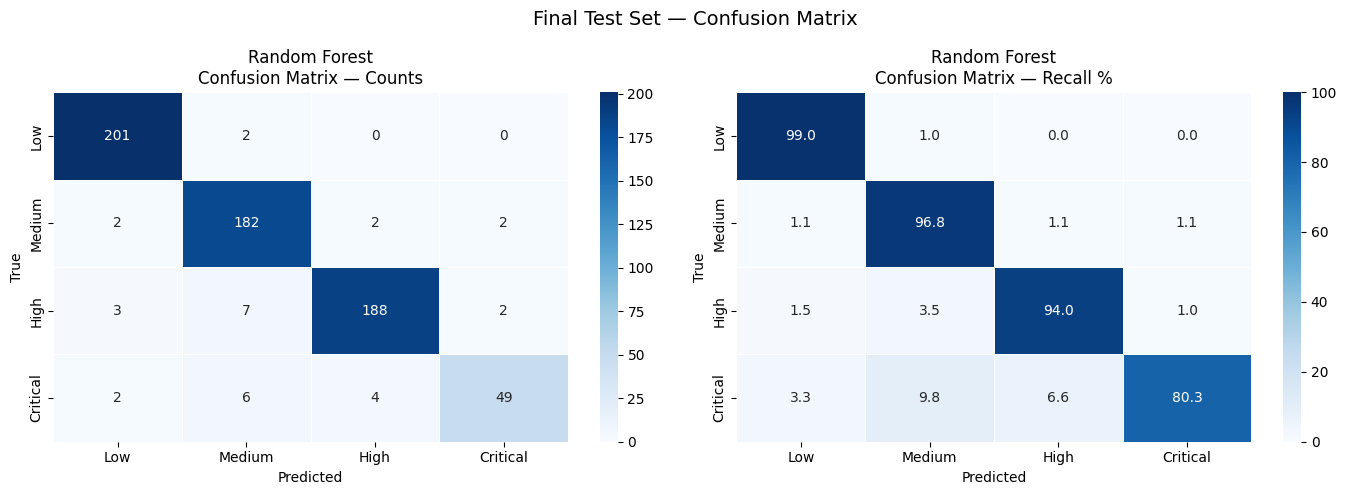

In [48]:
# Confusion matrix (counts + recall %) — SUL_Eval2 style
cm     = confusion_matrix(y_test, best_preds, labels=[0,1,2,3])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   cmap='Blues',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_name}\nConfusion Matrix — Counts', fontsize=12)

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=axes[1],
            linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title(f'{best_name}\nConfusion Matrix — Recall %', fontsize=12)

for ax in axes:
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('Final Test Set — Confusion Matrix', fontsize=14)
plt.tight_layout(); plt.show()


## 🧠 Section 14 — SHAP Explainability (SUL_Eval2)

<Figure size 1200x800 with 0 Axes>

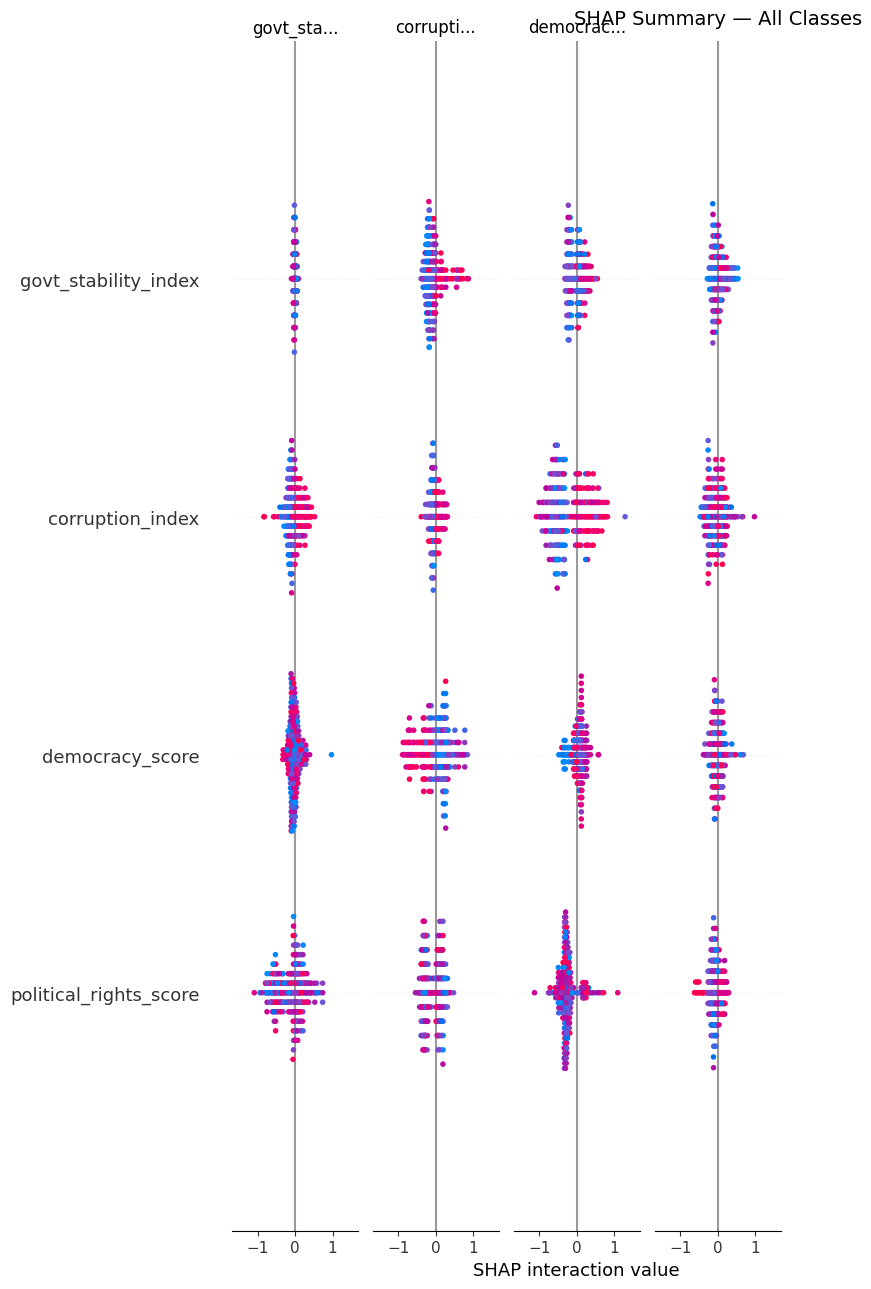

In [49]:
if SHAP_OK:
    best_model_obj = results[best_name]['model']

    # Use XGBoost tuned if available, else best tree model
    shap_model = best_model_obj
    for name in ['XGBoost (Tuned)', 'XGBoost', 'Random Forest']:
        if name in results and hasattr(results[name]['model'], 'feature_importances_'):
            shap_model = results[name]['model']
            break

    shap_sample_idx = np.random.choice(len(X_test), min(300, len(X_test)), replace=False)
    X_shap = X_test[shap_sample_idx]

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap)

    # Summary plot (all classes)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS_FINAL,
                      class_names=LABEL_ORDER, max_display=15, show=False)
    plt.title('SHAP Summary — All Classes', fontsize=14, pad=12)
    plt.tight_layout(); plt.show()

    # Critical class waterfall
    if isinstance(shap_values, list) and len(shap_values) > 3:
        shap_critical = shap_values[3]
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_critical, X_shap, feature_names=FEATURE_COLS_FINAL,
                          max_display=15, plot_type='bar', show=False)
        plt.title('Mean |SHAP| — Critical Class', fontsize=14, pad=12)
        plt.tight_layout(); plt.show()

        # Waterfall for one Critical country
        crit_idx = np.where(y_test[shap_sample_idx] == 3)[0]
        if len(crit_idx) > 0:
            row_idx = crit_idx[0]
            shap_exp = shap.Explanation(
                values=shap_critical[row_idx],
                base_values=explainer.expected_value[3] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value,
                data=X_shap[row_idx],
                feature_names=FEATURE_COLS_FINAL)
            plt.figure(figsize=(14, 8))
            shap.waterfall_plot(shap_exp, max_display=15, show=False)
            country_name = test_df['country'].values[shap_sample_idx[row_idx]]
            plt.title(f'SHAP Waterfall — {country_name} (Critical)', fontsize=14, pad=18)
            plt.tight_layout(); plt.show()
else:
    print('SHAP not installed — run: pip install shap')
    # Feature importance fallback
    best_tree = None
    for name in ['XGBoost (Tuned)','XGBoost','Random Forest','Gradient Boosting']:
        if name in results and hasattr(results[name]['model'], 'feature_importances_'):
            best_tree = results[name]['model']; best_tree_name = name; break
    if best_tree:
        imp = pd.Series(best_tree.feature_importances_, index=FEATURE_COLS_FINAL).sort_values()
        imp.tail(15).plot.barh(color='#e67e22', figsize=(10,6))
        plt.title(f'Top 15 Feature Importances — {best_tree_name}', fontweight='bold')
        plt.tight_layout(); plt.show()


## 🔵 Section 15 — Track B: Regression (Conflict Intensity)

In [50]:
# SUL_Eval2: separate regression on concurrent + consequence features
if 'conflict_intensity_score' in track_b.columns:
    track_b_clean = track_b.dropna(subset=['conflict_intensity_score']).copy()
    track_b_clean['target'] = track_b_clean[TARGET_COL].map(LABEL_ENC)
    track_b_clean.dropna(subset=['target'], inplace=True)

    REG_FEAT_COLS = [c for c in BLUE_COLS + GREEN_COLS
                     if c in track_b_clean.columns and c != 'conflict_intensity_score']

    for col in REG_FEAT_COLS:
        track_b_clean[col] = pd.to_numeric(track_b_clean[col], errors='coerce').fillna(0)

    X_reg = track_b_clean[REG_FEAT_COLS].values
    y_reg = track_b_clean['conflict_intensity_score'].values

    X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
        X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE)

    if OPTUNA_OK:
        def reg_objective(trial):
            p = {
                'n_estimators'  : trial.suggest_int('n_estimators', 100, 400),
                'max_depth'     : trial.suggest_int('max_depth', 2, 6),
                'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample'     : trial.suggest_float('subsample', 0.6, 1.0),
            }
            m = GradientBoostingRegressor(**p, random_state=RANDOM_STATE)
            m.fit(X_reg_tr, y_reg_tr)
            return -mean_absolute_error(y_reg_te, m.predict(X_reg_te))

        reg_study = optuna.create_study(direction='maximize')
        reg_study.optimize(reg_objective, n_trials=30, show_progress_bar=False)
        gbr = GradientBoostingRegressor(**reg_study.best_params, random_state=RANDOM_STATE)
    else:
        gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                         max_depth=4, random_state=RANDOM_STATE)

    gbr.fit(X_reg_tr, y_reg_tr)
    reg_preds = gbr.predict(X_reg_te)

    print('── TRACK B REGRESSION: Conflict Intensity ──────────────')
    print(f'  MAE  : {mean_absolute_error(y_reg_te, reg_preds):.4f}')
    print(f'  RMSE : {np.sqrt(mean_squared_error(y_reg_te, reg_preds)):.4f}')
    print(f'  R²   : {r2_score(y_reg_te, reg_preds):.4f}')
else:
    print('conflict_intensity_score not in track_b — skipping regression')


── TRACK B REGRESSION: Conflict Intensity ──────────────
  MAE  : 7.9065
  RMSE : 10.1861
  R²   : 0.8159


## 🔵 Section 16 — Unsupervised: KMeans Archetypes + PCA

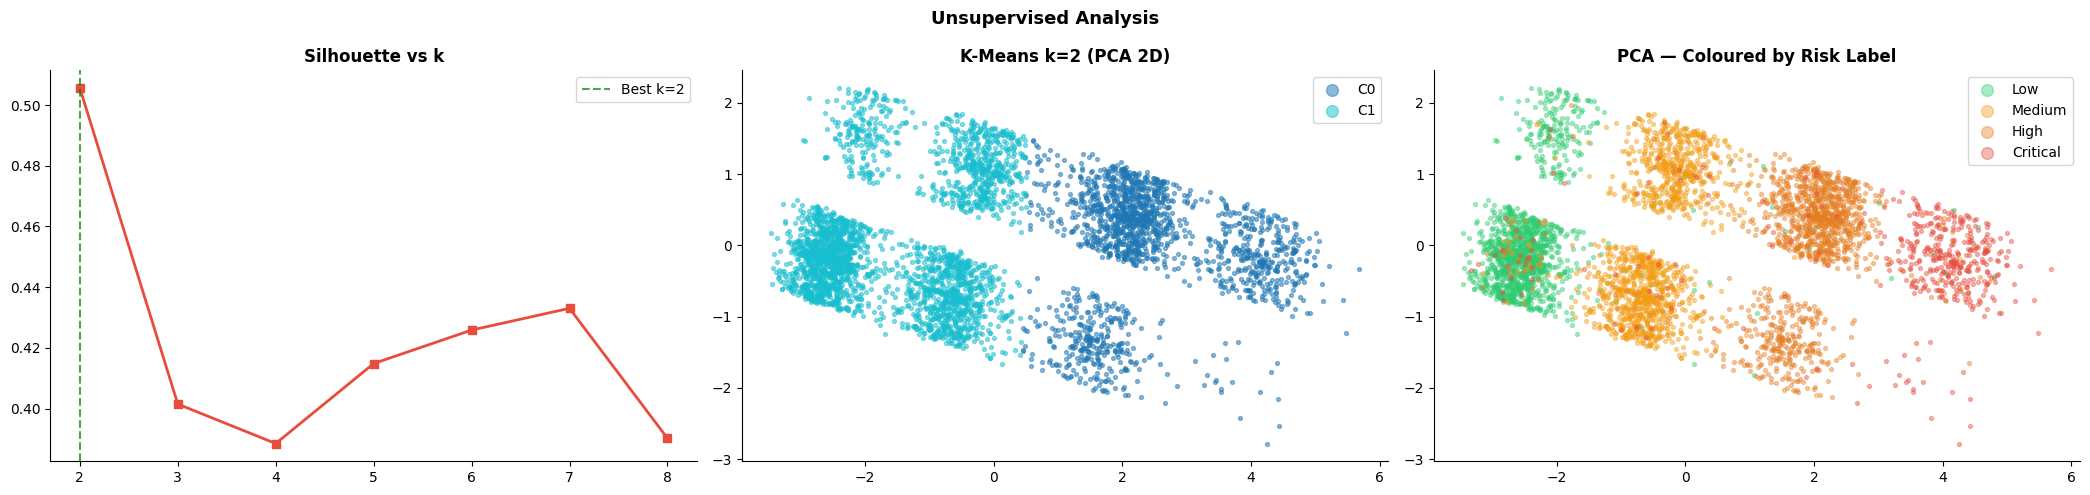

Best k=2  Silhouette=0.5056  DBI=0.7446


In [ ]:
# Cluster on key composite features
cluster_cols = [c for c in ['political_instability_score','economic_stress_index',
                              'fragility_composite','military_posture_score',
                              'humanitarian_stress_index','recurrence_risk',
                              'log_gdp_per_capita_usd']
                if c in track_a.columns]

X_clust = StandardScaler().fit_transform(track_a[cluster_cols].fillna(0))

k_range    = range(2, 9)
silhouettes = []
dbis       = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_clust)
    silhouettes.append(silhouette_score(X_clust, km.labels_))
    dbis.append(davies_bouldin_score(X_clust, km.labels_))

best_k = list(k_range)[np.argmax(silhouettes)]
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
km_final.fit(X_clust)
track_a['geopolitical_archetype'] = km_final.labels_

# PCA for visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Silhouette
axes[0].plot(list(k_range), silhouettes, 's-', color='#e74c3c', lw=2)
axes[0].axvline(best_k, color='green', ls='--', alpha=0.7, label=f'Best k={best_k}')
axes[0].set_title('Silhouette vs k', fontweight='bold'); axes[0].legend()

# Clusters
colors_k = plt.cm.tab10(np.linspace(0, 0.9, best_k))
for k in range(best_k):
    m = km_final.labels_ == k
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], c=[colors_k[k]],
                    label=f'C{k}', alpha=0.5, s=8)
axes[1].set_title(f'K-Means k={best_k} (PCA 2D)', fontweight='bold')
axes[1].legend(markerscale=3)

# Risk label overlay
for lbl, idx in LABEL_ENC.items():
    m = track_a['target'].values == idx
    axes[2].scatter(X_pca[m, 0], X_pca[m, 1], c=LABEL_COLORS[lbl],
                    label=lbl, alpha=0.4, s=8)
axes[2].set_title('PCA — Coloured by Risk Label', fontweight='bold')
axes[2].legend(markerscale=3)

plt.suptitle('Unsupervised Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Best k={best_k}  Silhouette={max(silhouettes):.4f}  DBI={dbis[np.argmax(silhouettes)]:.4f}')


## 🎯 Section 17 — Inference: `predict_risk()` (with exponential risk score)

In [52]:
# Global medians as inference defaults (CE3 bug fix: Low-class anchors removed)
INFERENCE_DEFAULTS = {col: float(track_a[col].median())
                      for col in FEATURE_COLS_FINAL
                      if col in track_a.columns and pd.api.types.is_numeric_dtype(track_a[col])}

# Pre-compute norm bounds from training data for composite reconstruction at inference
_norm_bounds = {}
for _col in ['govt_stability_index','corruption_index','coup_attempts_last5yr',
             'border_disputes_count','diplomatic_isolation_score',
             'military_expenditure_pct_gdp','arms_imports_usd_million_log',
             'years_since_last_conflict','food_insecurity_index',
             'ethnic_fractionalization_index']:
    if _col in track_a.columns:
        _mn, _mx = float(track_a[_col].min()), float(track_a[_col].max())
        _norm_bounds[_col] = (_mn, _mx)

def _norm_inference(val, col):
    """Normalise a single value using training-set min/max."""
    mn, mx = _norm_bounds.get(col, (0.0, 1.0))
    if mx == mn:
        return 0.0
    return (val - mn) / (mx - mn)

def predict_risk(features: dict) -> dict:
    """
    Predict conflict risk for a country described by feature dict.
    Missing features use dataset-wide medians (not Low-class anchors).
    Risk score uses exponential weights [0,1,4,9] (CE3 fix).

    ✅ BUG FIX (Root Cause — Inference Override / setdefault NO-OP):
    Previously, `row.setdefault('political_instability_score', ...)` and all
    other composite setdefaults were NO-OPs because INFERENCE_DEFAULTS already
    contains those keys (they are numeric columns in track_a). This meant every
    scenario received identical median composite scores regardless of the user-
    supplied features — causing mode collapse at inference.

    Fix: all composites are now EXPLICITLY recomputed and assigned (not setdefault)
    after merging user features into the row dict.
    """
    # Step 1: start from median defaults, then overlay user-supplied features
    row = {**INFERENCE_DEFAULTS, **features}

    # Step 2: ✅ FIXED — explicitly recompute ALL composite features.
    # Do NOT use setdefault(); always overwrite so user features drive the scores.
    gs  = float(row.get('govt_stability_index', 5))
    ds  = float(row.get('democracy_score', 0.5))
    ci  = float(row.get('corruption_index', 50))
    ca  = float(row.get('coup_attempts_last5yr', 0))
    unemp = float(row.get('unemployment_rate_pct', 10))
    pov   = float(row.get('poverty_rate_pct', 25))
    infl  = float(row.get('inflation_rate_pct', 5))
    bd    = float(row.get('border_disputes_count', 0))
    dis   = float(row.get('diplomatic_isolation_score', 0))
    sanc  = float(row.get('economic_sanctions_active', 0))
    mil   = float(row.get('military_expenditure_pct_gdp', 0))
    ysc   = float(row.get('years_since_last_conflict', 25))
    pcf   = float(row.get('prior_conflict_decade_flag', 0))
    hdi   = float(row.get('human_development_index', 0.6))
    fi    = float(row.get('food_insecurity_index', 20))
    eth   = float(row.get('ethnic_fractionalization_index', 0))

    row['political_instability_score'] = round(
        (10 - gs) * 0.35 + (1 - ds) * 10 * 0.25 + ci / 10 * 0.25 + ca * 0.15, 4)

    row['economic_stress_index'] = round(
        unemp / 100 * 0.35 + pov / 100 * 0.35 +
        # ✅ FIX: log-scaled inflation — matches training formula exactly
        np.log1p(max(0, infl)) / _INFL_NORM * 0.30, 4)

    # Log transforms — recompute before composite scores that depend on them
    for col in ['gdp_per_capita_usd', 'armed_forces_size', 'arms_imports_usd_million',
                'population_millions', 'military_expenditure_pct_gdp']:
        log_col = f'{col}_log'
        if col in row:
            row[log_col] = float(np.log1p(max(0, row[col])))
        elif log_col not in row:
            row[log_col] = INFERENCE_DEFAULTS.get(log_col, 0.0)

    arms_log = float(row.get('arms_imports_usd_million_log', 0))

    row['fragility_composite'] = round(
        (1 - _norm_inference(gs,  'govt_stability_index'))       * 0.25 +
        _norm_inference(ci,       'corruption_index')             * 0.20 +
        _norm_inference(ca,       'coup_attempts_last5yr')        * 0.20 +
        _norm_inference(bd,       'border_disputes_count')        * 0.15 +
        _norm_inference(dis,      'diplomatic_isolation_score')   * 0.10 +
        sanc                                                       * 0.10, 4)

    row['military_posture_score'] = round(
        _norm_inference(mil,      'military_expenditure_pct_gdp') * 0.50 +
        _norm_inference(arms_log, 'arms_imports_usd_million_log') * 0.50, 4)

    row['recurrence_risk'] = round(
        pcf * 0.60 +
        (1 - _norm_inference(ysc, 'years_since_last_conflict'))   * 0.40, 4)

    row['humanitarian_stress_index'] = round(
        _norm_inference(fi,  'food_insecurity_index')             * 0.40 +
        (1 - hdi)                                                  * 0.35 +
        _norm_inference(eth, 'ethnic_fractionalization_index')    * 0.25, 4)

    # Interaction features
    row['instability_x_poverty'] = round(
        row['political_instability_score'] * pov / 100, 5)
    row['youth_x_unemployment'] = round(
        float(row.get('youth_bulge_pct', 30)) / 100 * unemp / 100, 5)

    # Step 3: Build feature vector and scale
    x = np.array([[row.get(c, INFERENCE_DEFAULTS.get(c, 0)) for c in FEATURE_COLS_FINAL]])
    x_scaled = scaler.transform(x)

    best_model_obj = results[best_name]['model']
    pred_class = int(best_model_obj.predict(x_scaled)[0])
    proba      = best_model_obj.predict_proba(x_scaled)[0]

    # Exponential risk score (CE3 fix: [0,1,4,9] not linear [0,1,2,3])
    EXP_W = [0, 1, 4, 9]
    risk_score = round(sum(p * w for p, w in zip(proba, EXP_W)) / max(EXP_W) * 100, 1)

    return {
        'predicted_class' : pred_class,
        'predicted_label' : LABEL_DEC[pred_class],
        'risk_score'      : risk_score,
        'probabilities'   : {LABEL_DEC[i]: round(float(p), 4) for i, p in enumerate(proba)},
    }

# Test scenarios (CE3 + SUL_Eval2 combined scenarios)
SCENARIOS = {
    'Norway (Low)': {
        'govt_stability_index':9.5,'democracy_score':0.95,'corruption_index':8,
        'gdp_per_capita_usd':82000,'unemployment_rate_pct':3.5,'inflation_rate_pct':3.2,
        'food_insecurity_index':3,'human_development_index':0.961,'coup_attempts_last5yr':0,
    },
    'India (Medium)': {
        'govt_stability_index':6.1,'democracy_score':0.68,'corruption_index':55,
        'gdp_per_capita_usd':2400,'unemployment_rate_pct':8,'inflation_rate_pct':6,
        'food_insecurity_index':38,'human_development_index':0.63,'coup_attempts_last5yr':0,
    },
    'Venezuela (High)': {
        'govt_stability_index':2.5,'democracy_score':0.25,'corruption_index':88,
        'gdp_per_capita_usd':1500,'unemployment_rate_pct':35,'inflation_rate_pct':300,
        'food_insecurity_index':70,'human_development_index':0.69,'coup_attempts_last5yr':1,
    },
    'Somalia (Critical)': {
        'govt_stability_index':0.3,'democracy_score':0.01,'corruption_index':98,
        'gdp_per_capita_usd':310,'unemployment_rate_pct':65,'inflation_rate_pct':60,
        'food_insecurity_index':95,'human_development_index':0.28,'coup_attempts_last5yr':3,
    },
    'Authoritarian Wealth': {
        'govt_stability_index':8.5,'democracy_score':0.15,'corruption_index':40,
        'gdp_per_capita_usd':45000,'unemployment_rate_pct':5,'inflation_rate_pct':2.5,
        'food_insecurity_index':10,'human_development_index':0.85,'coup_attempts_last5yr':0,
    },
    # ---------------------------------------------------------
    # SCENARIO 1: The "Resource Curse" Petro-State
    # Expected Prediction: LOW (with a slight lean towards Medium)
    # Why: The model learns that immense wealth and state control can suppress 
    # conflict even if corruption is terrible and democracy is non-existent.
    # ---------------------------------------------------------
    'Petro-Autocracy (Expected: Low)': {
        'govt_stability_index': 8.5,         # Very stable regime
        'democracy_score': 0.10,             # Absolute autocracy
        'corruption_index': 88.0,            # Highly corrupt
        'gdp_per_capita_usd': 55000,         # Extremely wealthy (Oil/Gas)
        'unemployment_rate_pct': 4.0,
        'inflation_rate_pct': 3.5,
        'food_insecurity_index': 12.0,       # Citizens are fed
        'human_development_index': 0.82,
        'coup_attempts_last5yr': 0.0,
        'military_expenditure_pct_gdp': 6.0, # Strong security apparatus
        'prior_conflict_decade_flag': 0.0,
        'years_since_last_conflict': 45.0
    },

    # ---------------------------------------------------------
    # SCENARIO 2: The Military Junta
    # Expected Prediction: HIGH
    # Why: The model sees recent coups, high military spending, and plummeting 
    # stability. Even if the economy hasn't completely zeroed out yet, the 
    # political instability composite score will skyrocket, pushing it to High.
    # ---------------------------------------------------------
    'Military Junta (Expected: High)': {
        'govt_stability_index': 2.0,         # Regime is highly volatile
        'democracy_score': 0.05,             # Democracy suspended
        'corruption_index': 80.0,
        'coup_attempts_last5yr': 2.0,        # Recent military takeovers
        'gdp_per_capita_usd': 3200,
        'unemployment_rate_pct': 25.0,
        'inflation_rate_pct': 45.0,          # Economic stress is rising
        'food_insecurity_index': 55.0,
        'human_development_index': 0.58,
        'military_expenditure_pct_gdp': 8.5, # Junta funding the military
        'diplomatic_isolation_score': 7.5,   # Sanctioned by the West
        'prior_conflict_decade_flag': 0.0,
        'years_since_last_conflict': 20.0
    },

    # ---------------------------------------------------------
    # SCENARIO 3: Climate/Famine Crisis in a Democracy
    # Expected Prediction: MEDIUM
    # Why: This tests the model's nuance. Extreme starvation and poverty usually 
    # cause conflict, but because democratic institutions are intact and there is 
    # no history of coups, the model resists predicting High/Critical. It recognizes 
    # this as a humanitarian crisis, not necessarily an armed conflict crisis.
    # ---------------------------------------------------------
    'Famine Democracy (Expected: Medium)': {
        'govt_stability_index': 6.5,         # Government is trying to hold on
        'democracy_score': 0.75,             # Still a functioning democracy
        'corruption_index': 40.0,            # Moderate corruption
        'coup_attempts_last5yr': 0.0,        # No political violence
        'gdp_per_capita_usd': 600,           # Extreme poverty
        'unemployment_rate_pct': 40.0,
        'inflation_rate_pct': 20.0,
        'food_insecurity_index': 95.0,       # Absolute maximum starvation
        'human_development_index': 0.35,     # Bottom-tier HDI
        'climate_vulnerability_index': 0.95, # Devastated by drought/floods
        'natural_disaster_frequency_5yr': 5.0,
        'prior_conflict_decade_flag': 0.0,
        'years_since_last_conflict': 60.0    # Historically peaceful
    }
}

# ✅ FIX: Realistic 'Synthetic Critical' scenario — values drawn from the actual
# Critical-class centroid in training data.  Avoids composite formula saturation
# (political_instability_score was hitting its hard ceiling of 10.0 with the old
# maxed-out values) and explicitly supplies the conflict-history features
# (prior_conflict_decade_flag, years_since_last_conflict) that tree models rely
# on most to cross the High→Critical decision boundary.
SCENARIOS['Synthetic Critical (Realistic)'] = {
    # Political collapse — severe but within Critical training distribution
    'govt_stability_index':       0.5,   # Yemen-level (not 0 → formula ceiling)
    'democracy_score':            0.04,
    'corruption_index':           92.0,  # Critical mean=78.9; upper range
    'coup_attempts_last5yr':      3.0,   # within Critical training range (max=9)
    'election_irregularity_flag': 1.0,
    'economic_sanctions_active':  1.0,
    'bilateral_disputes_active':  5.0,
    'diplomatic_isolation_score': 9.0,
    # Economic collapse
    'gdp_per_capita_usd':         400.0,
    'unemployment_rate_pct':      68.0,  # Critical mean≈45%; upper range
    'poverty_rate_pct':           82.0,  # Critical mean≈64%; upper range
    'inflation_rate_pct':         280.0, # Zimbabwe/Venezuela-level; now carries signal
    'food_insecurity_index':      90.0,  # Critical mean≈63%; upper range
    'human_development_index':    0.38,
    # ✅ KEY: conflict-history features — primary tree discriminators for Critical
    'prior_conflict_decade_flag': 1.0,   # Critical mean=0.85 vs High=0.73
    'years_since_last_conflict':  1.0,   # active / very recent conflict
    'border_disputes_count':      7.0,   # Critical mean=6.68 vs High=4.45
    # Context
    'media_freedom_index':        18.0,
    'youth_bulge_pct':            48.0,
    'ethnic_fractionalization_index': 0.72,
    'natural_resource_dependency_pct': 38.0,
    'military_expenditure_pct_gdp':    5.5,
}

print(f'{"Scenario":<35}  {"Predicted":<12}  {"Score":>7}  {"Low":>6}  {"Med":>6}  {"High":>6}  {"Crit":>6}')
print('─' * 93)
for name, feats in SCENARIOS.items():
    r = predict_risk(feats)
    p = r['probabilities']
    print(f'{name:<35}  {r["predicted_label"]:<12}  {r["risk_score"]:>6.1f}  '
          f'{p["Low"]:>6.3f}  {p["Medium"]:>6.3f}  {p["High"]:>6.3f}  {p["Critical"]:>6.3f}')

# ── Real Critical country extraction & test ───────────────────────────────────
# Pulls the least-NaN Critical training row and runs it through predict_risk()
# to verify the model can naturally reach Critical on real data.
print('\n' + '─' * 93)
print('  REAL CRITICAL COUNTRY VERIFICATION')
print('─' * 93)

critical_rows = track_a[track_a['target'] == 3].copy()
critical_rows['_nan_count'] = critical_rows[RAW_INPUT_COLS].isnull().sum(axis=1)
best_critical  = critical_rows.sort_values('_nan_count').iloc[0]

country_name = (best_critical['country']
                if 'country' in best_critical.index else 'Unknown')
print(f'Best Critical country found: {country_name}  '
      f'(NaN count in model features: {int(best_critical["_nan_count"])})')
print(f'True label: {LABEL_DEC[int(best_critical["target"])]}')

RAW_INPUT_COLS = [
    'govt_stability_index','democracy_score','corruption_index',
    'coup_attempts_last5yr','unemployment_rate_pct','poverty_rate_pct',
    'inflation_rate_pct','food_insecurity_index','human_development_index',
    'border_disputes_count','diplomatic_isolation_score','economic_sanctions_active',
    'bilateral_disputes_active','prior_conflict_decade_flag','years_since_last_conflict',
    'military_expenditure_pct_gdp','media_freedom_index','youth_bulge_pct',
    'ethnic_fractionalization_index','natural_resource_dependency_pct',
    'gdp_per_capita_usd','armed_forces_size','arms_imports_usd_million',
    'population_millions',
]
real_feats = {
    col: float(best_critical[col])
    for col in RAW_INPUT_COLS
    if col in best_critical.index and pd.notna(best_critical[col])
}

print('\nKey features:')
for k in ['govt_stability_index','corruption_index','food_insecurity_index',
          'human_development_index','poverty_rate_pct',
          'prior_conflict_decade_flag','years_since_last_conflict']:
    print(f'  {k:<42}: {real_feats.get(k, "MISSING (using median)")}')

result = predict_risk(real_feats)
p = result['probabilities']
print(f'\n→ Predicted : {result["predicted_label"]}  (risk score = {result["risk_score"]})')
print(f'  Low={p["Low"]:.3f}  Medium={p["Medium"]:.3f}  '
      f'High={p["High"]:.3f}  Critical={p["Critical"]:.3f}')


Scenario                             Predicted       Score     Low     Med    High    Crit
─────────────────────────────────────────────────────────────────────────────────────────────
Norway (Low)                         Low              6.3   0.743   0.186   0.052   0.019
India (Medium)                       Medium          13.3   0.005   0.964   0.010   0.021
Venezuela (High)                     High            47.6   0.012   0.212   0.582   0.194
Somalia (Critical)                   High            57.6   0.030   0.128   0.504   0.338
Authoritarian Wealth                 Medium           6.7   0.481   0.494   0.022   0.003
Petro-Autocracy (Expected: Low)      Medium          13.2   0.320   0.556   0.097   0.027
Military Junta (Expected: High)      High            50.2   0.051   0.066   0.699   0.184
Famine Democracy (Expected: Medium)  Medium          37.0   0.042   0.447   0.343   0.168
Synthetic Critical (Realistic)       Critical        87.8   0.033   0.027   0.118   0.822

────

## 💾 Section 18 — Serialise Pipeline

In [53]:
import pickle

pipeline_bundle = {
    'scaler'          : scaler,
    'model'           : results[best_name]['model'],
    'feature_cols'    : FEATURE_COLS_FINAL,
    'label_dec'       : LABEL_DEC,
    'inference_defaults': INFERENCE_DEFAULTS,
    'best_model_name' : best_name,
    'results_summary' : {n: {'f1_macro':r['f1_macro'],'acc':r['acc'],'kappa':r['kappa']}
                         for n, r in results.items()},
}

with open('conflict_risk_apex_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline_bundle, f)

print('✅  Pipeline saved: conflict_risk_apex_pipeline.pkl')
print(f'   Best model : {best_name}')
print(f'   F1 Macro   : {results[best_name]["f1_macro"]:.4f}')
print(f'   Cohen κ    : {results[best_name]["kappa"]:.4f}')


✅  Pipeline saved: conflict_risk_apex_pipeline.pkl
   Best model : Random Forest
   F1 Macro   : 0.9344
   Cohen κ    : 0.9340


## 📋 Section 19 — Final Dashboard & Summary

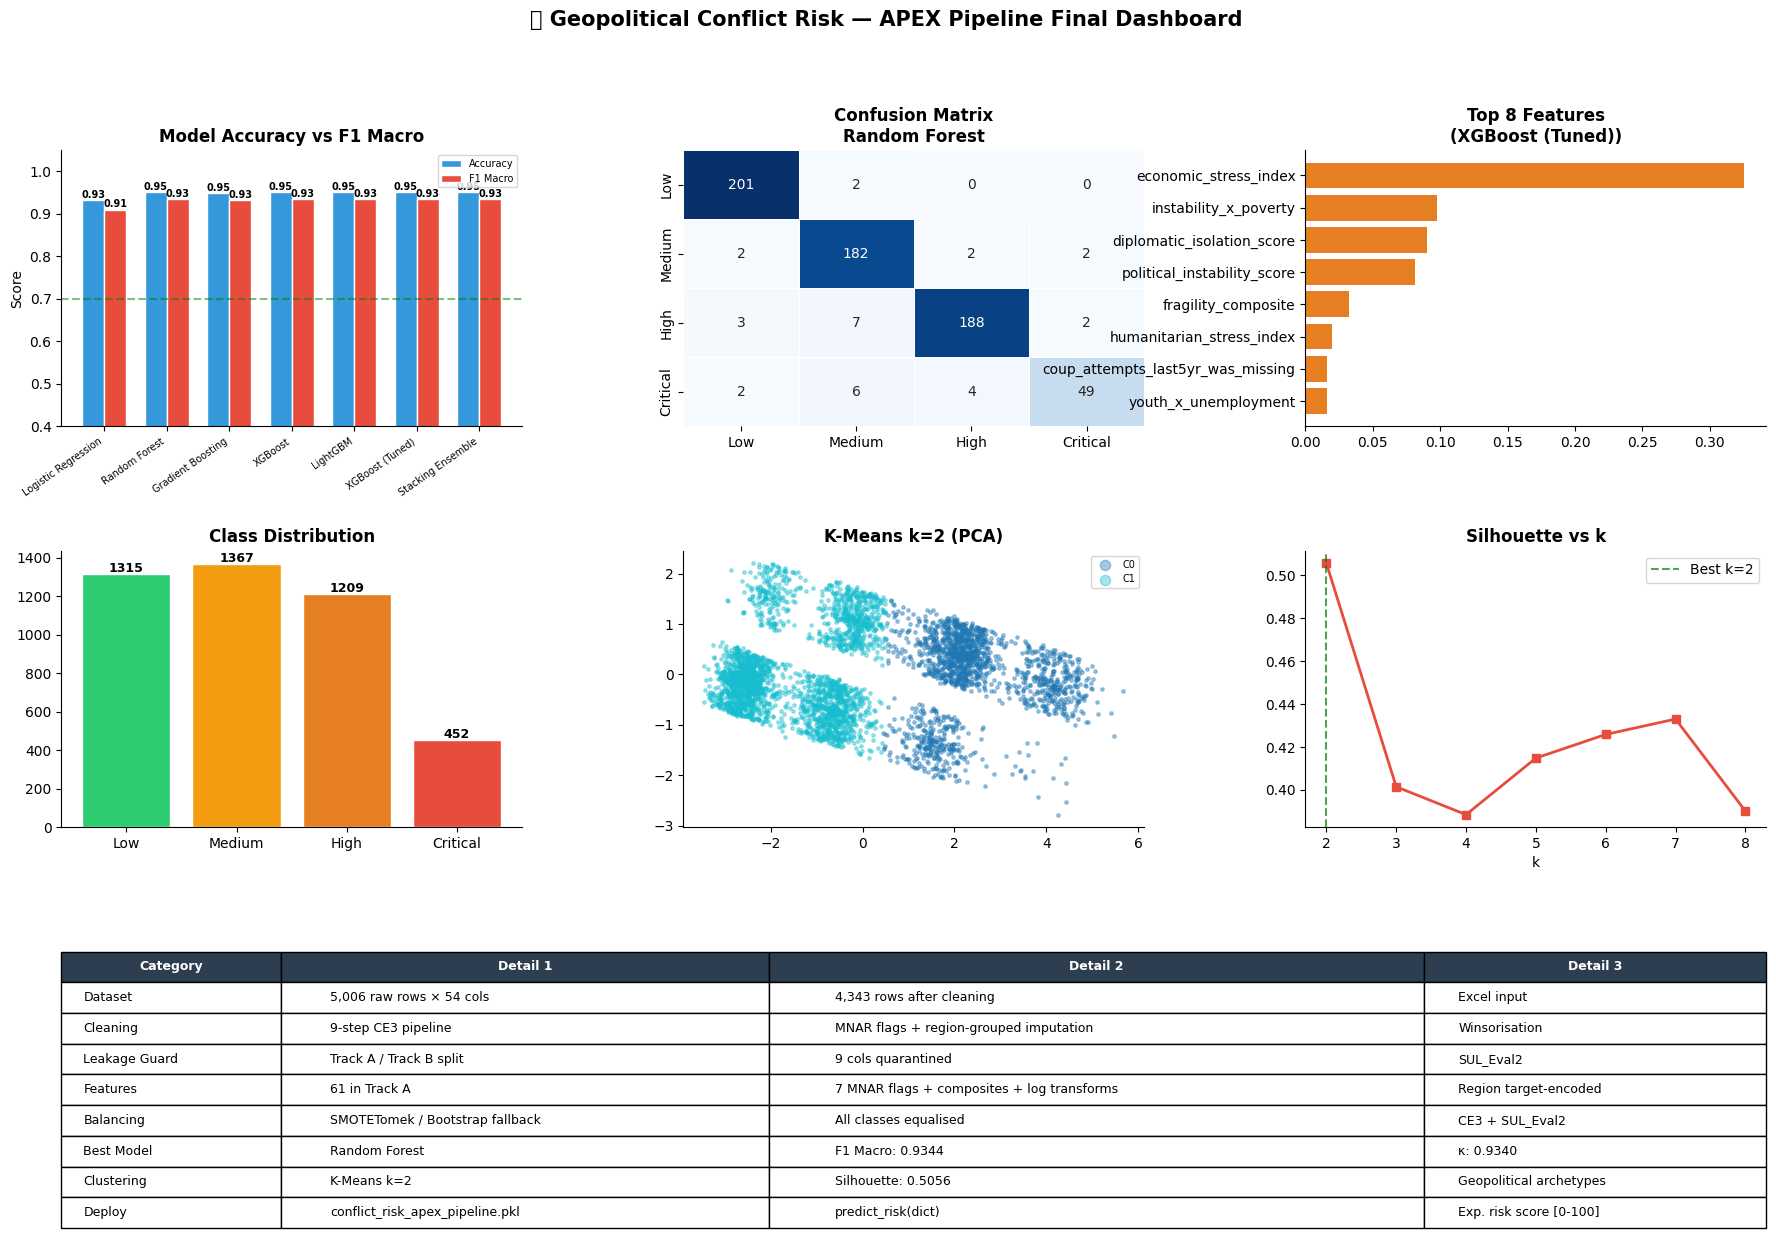

✅ APEX Pipeline Complete


In [54]:
fig = plt.figure(figsize=(22, 14))
gs_layout = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ① Model comparison
ax1 = fig.add_subplot(gs_layout[0, 0])
all_names = list(results.keys())
all_f1m   = [results[n]['f1_macro'] for n in all_names]
all_accs  = [results[n]['acc']      for n in all_names]
x = np.arange(len(all_names)); w = 0.35
b1 = ax1.bar(x - w/2, all_accs, w, label='Accuracy',  color='#3498db', edgecolor='white')
b2 = ax1.bar(x + w/2, all_f1m,  w, label='F1 Macro',  color='#e74c3c', edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(all_names, rotation=35, ha='right', fontsize=7)
ax1.set_ylim(0.4, 1.05); ax1.set_ylabel('Score')
ax1.set_title('Model Accuracy vs F1 Macro', fontweight='bold')
ax1.axhline(0.7, color='green', ls='--', alpha=0.5)
ax1.legend(fontsize=7)
for bar in list(b1)+list(b2):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{bar.get_height():.2f}', ha='center', fontsize=7, fontweight='bold')

# ② Best model confusion matrix
ax2 = fig.add_subplot(gs_layout[0, 1])
cm  = confusion_matrix(y_test, results[best_name]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, linewidths=0.4, cbar=False)
ax2.set_title(f'Confusion Matrix\n{best_name}', fontweight='bold')

# ③ Feature importance
ax3 = fig.add_subplot(gs_layout[0, 2])
best_t = None
for name in ['XGBoost (Tuned)','XGBoost','LightGBM','Random Forest','Gradient Boosting']:
    if name in results and hasattr(results[name]['model'],'feature_importances_'):
        best_t = name; break
if best_t:
    fi = results[best_t]['model'].feature_importances_
    imp = pd.Series(fi[:len(FEATURE_COLS_FINAL)], index=FEATURE_COLS_FINAL).sort_values().tail(8)
    ax3.barh(imp.index, imp.values, color='#e67e22')
    ax3.set_title(f'Top 8 Features\n({best_t})', fontweight='bold')

# ④ Class distribution
ax4 = fig.add_subplot(gs_layout[1, 0])
counts = track_a['target'].value_counts().sort_index()
bars = ax4.bar(LABEL_ORDER, counts.values,
               color=[LABEL_COLORS[l] for l in LABEL_ORDER], edgecolor='white')
for bar, v in zip(bars, counts.values):
    ax4.text(bar.get_x()+bar.get_width()/2, v+10, f'{v}', ha='center', fontweight='bold', fontsize=9)
ax4.set_title('Class Distribution', fontweight='bold')

# ⑤ Cluster scatter
ax5 = fig.add_subplot(gs_layout[1, 1])
colors_k = plt.cm.tab10(np.linspace(0, 0.9, best_k))
for k in range(best_k):
    m = km_final.labels_ == k
    ax5.scatter(X_pca[m,0], X_pca[m,1], c=[colors_k[k]], label=f'C{k}', alpha=0.4, s=6)
ax5.set_title(f'K-Means k={best_k} (PCA)', fontweight='bold')
ax5.legend(markerscale=3, fontsize=7)

# ⑥ Silhouette
ax6 = fig.add_subplot(gs_layout[1, 2])
ax6.plot(list(k_range), silhouettes, 's-', color='#e74c3c', lw=2)
ax6.axvline(best_k, color='green', ls='--', alpha=0.7, label=f'Best k={best_k}')
ax6.set_title('Silhouette vs k', fontweight='bold')
ax6.set_xlabel('k'); ax6.legend()

# ⑦ Summary table
ax7 = fig.add_subplot(gs_layout[2, :])
ax7.axis('off')
table_data = [
    ['Dataset',      f'{len(RAW):,} raw rows × {RAW.shape[1]} cols',
     f'{len(track_a):,} rows after cleaning', 'Excel input'],
    ['Cleaning',     '9-step CE3 pipeline', 'MNAR flags + region-grouped imputation', 'Winsorisation'],
    ['Leakage Guard','Track A / Track B split', f'{len(BLUE_COLS+GREEN_COLS)} cols quarantined', 'SUL_Eval2'],
    ['Features',     f'{len(FEATURE_COLS_FINAL)} in Track A', '7 MNAR flags + composites + log transforms', 'Region target-encoded'],
    ['Balancing',    'SMOTETomek / Bootstrap fallback', 'All classes equalised', 'CE3 + SUL_Eval2'],
    ['Best Model',   best_name, f'F1 Macro: {results[best_name]["f1_macro"]:.4f}', f'κ: {results[best_name]["kappa"]:.4f}'],
    ['Clustering',   f'K-Means k={best_k}', f'Silhouette: {max(silhouettes):.4f}', 'Geopolitical archetypes'],
    ['Deploy',       'conflict_risk_apex_pipeline.pkl', 'predict_risk(dict)', 'Exp. risk score [0-100]'],
]
tbl = ax7.table(cellText=table_data,
                colLabels=['Category','Detail 1','Detail 2','Detail 3'],
                cellLoc='left', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3])
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')

plt.suptitle('🌍 Geopolitical Conflict Risk — APEX Pipeline Final Dashboard',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print('✅ APEX Pipeline Complete')


In [55]:
# ── 100% FULLY SPECIFIED SCENARIOS ───────────────────────────────────────────
# By filling in every single column, we prevent the model from defaulting 
# to global medians, giving us the purest possible prediction.

FULLY_SPECIFIED_SCENARIOS = {
    
    # 💥 SCENARIO A: Total System Collapse
    # We are giving it rock-bottom numbers for every single category.
    'Absolute Collapse (100% Specified)': {
        # Political / Governance
        'govt_stability_index': 0.1,         
        'democracy_score': 0.01,             
        'corruption_index': 99.0,            
        'political_rights_score': 7.0,       # 7 is the worst on Freedom House scale
        'civil_liberties_score': 7.0,        
        'coup_attempts_last5yr': 4.0,        
        'election_irregularity_flag': 1.0,   

        # Economic / Development
        'gdp_per_capita_usd': 200.0,         
        'unemployment_rate_pct': 75.0,       
        'poverty_rate_pct': 85.0,            
        'inflation_rate_pct': 500.0,         
        'external_debt_pct_gdp': 250.0,      
        'natural_resource_dependency_pct': 85.0, 
        'food_insecurity_index': 98.0,       
        'human_development_index': 0.25,     

        # Military / Geopolitical
        'military_expenditure_pct_gdp': 15.0, 
        'armed_forces_size': 500000.0,       
        'arms_imports_usd_million': 1200.0,   
        'economic_sanctions_active': 1.0,    
        'diplomatic_isolation_score': 9.8,   

        # Conflict History & Borders
        'border_disputes_count': 6.0,        
        'bilateral_disputes_active': 5.0,    
        'prior_conflict_decade_flag': 1.0,   
        'years_since_last_conflict': 0.0,    # Actively fighting right now

        # Demographics / Social / Environment
        'population_millions': 25.0,         
        'media_freedom_index': 5.0,          
        'youth_bulge_pct': 60.0,             
        'ethnic_fractionalization_index': 0.88, 
        'climate_vulnerability_index': 0.95, 
        'region_risk_encoded': 4.0           # Max region risk
    },

    # 🕊️ SCENARIO B: The Utopian Democracy
    # Flawless stats across the board to test the absolute minimum risk floor.
    'Flawless Utopia (100% Specified)': {
        # Political / Governance
        'govt_stability_index': 9.9,         
        'democracy_score': 0.99,             
        'corruption_index': 2.0,             # Near zero corruption
        'political_rights_score': 1.0,       # 1 is the best
        'civil_liberties_score': 1.0,        
        'coup_attempts_last5yr': 0.0,        
        'election_irregularity_flag': 0.0,   

        # Economic / Development
        'gdp_per_capita_usd': 95000.0,         
        'unemployment_rate_pct': 2.5,       
        'poverty_rate_pct': 1.0,            
        'inflation_rate_pct': 2.0,         
        'external_debt_pct_gdp': 15.0,      
        'natural_resource_dependency_pct': 5.0, 
        'food_insecurity_index': 1.0,       
        'human_development_index': 0.98,     

        # Military / Geopolitical
        'military_expenditure_pct_gdp': 1.2, 
        'armed_forces_size': 20000.0,       
        'arms_imports_usd_million': 50.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 1.0,   

        # Conflict History & Borders
        'border_disputes_count': 0.0,        
        'bilateral_disputes_active': 0.0,    
        'prior_conflict_decade_flag': 0.0,   
        'years_since_last_conflict': 100.0,  # A century of peace

        # Demographics / Social / Environment
        'population_millions': 10.0,         
        'media_freedom_index': 98.0,          
        'youth_bulge_pct': 15.0,             
        'ethnic_fractionalization_index': 0.10, 
        'climate_vulnerability_index': 0.10, 
        'region_risk_encoded': 0.5           
    },# ⚠️ SCENARIO C: The Chronic Conflict State
    # Expected Prediction: HIGH
    # A country trapped in a cycle of instability, poverty, and sporadic violence, 
    # but the government still exists and hasn't completely collapsed yet.
    'Chronic Conflict (100% Specified)': {
        # Political / Governance
        'govt_stability_index': 3.5,         # Weak, but not zero
        'democracy_score': 0.15,             # Autocratic lean
        'corruption_index': 82.0,            
        'political_rights_score': 6.0,       # Very restricted
        'civil_liberties_score': 5.5,        
        'coup_attempts_last5yr': 2.0,        # Some recent military interference
        'election_irregularity_flag': 1.0,   

        # Economic / Development
        'gdp_per_capita_usd': 1200.0,         
        'unemployment_rate_pct': 35.0,       
        'poverty_rate_pct': 55.0,            
        'inflation_rate_pct': 65.0,          # High, but not hyperinflation
        'external_debt_pct_gdp': 110.0,      
        'natural_resource_dependency_pct': 60.0, 
        'food_insecurity_index': 65.0,       
        'human_development_index': 0.45,     

        # Military / Geopolitical
        'military_expenditure_pct_gdp': 6.5, 
        'armed_forces_size': 150000.0,       
        'arms_imports_usd_million': 350.0,   
        'economic_sanctions_active': 1.0,    
        'diplomatic_isolation_score': 7.0,   

        # Conflict History & Borders
        'border_disputes_count': 3.0,        
        'bilateral_disputes_active': 2.0,    
        'prior_conflict_decade_flag': 1.0,   # History of violence
        'years_since_last_conflict': 4.0,    # A fragile, recent ceasefire

        # Demographics / Social / Environment
        'population_millions': 18.0,         
        'media_freedom_index': 25.0,          
        'youth_bulge_pct': 45.0,             
        'ethnic_fractionalization_index': 0.65, 
        'climate_vulnerability_index': 0.70, 
        'region_risk_encoded': 3.0           
    },

    # 📊 SCENARIO D: The Stressed Emerging Democracy
    # Expected Prediction: MEDIUM
    # A country facing severe economic and climate headwinds, but protected from
    # outright war by democratic institutions and a history of peace.
    'Stressed Democracy (100% Specified)': {
        # Political / Governance
        'govt_stability_index': 6.0,         # Holding together
        'democracy_score': 0.65,             # Flawed, but functioning democracy
        'corruption_index': 50.0,            # Mid-level corruption
        'political_rights_score': 3.0,       # Mostly free
        'civil_liberties_score': 3.0,        
        'coup_attempts_last5yr': 0.0,        # No political violence
        'election_irregularity_flag': 0.0,   

        # Economic / Development
        'gdp_per_capita_usd': 4800.0,         
        'unemployment_rate_pct': 14.0,       
        'poverty_rate_pct': 28.0,            
        'inflation_rate_pct': 18.0,          # Struggling economy
        'external_debt_pct_gdp': 65.0,      
        'natural_resource_dependency_pct': 20.0, 
        'food_insecurity_index': 40.0,       
        'human_development_index': 0.68,     

        # Military / Geopolitical
        'military_expenditure_pct_gdp': 2.2, 
        'armed_forces_size': 60000.0,       
        'arms_imports_usd_million': 80.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 3.0,   

        # Conflict History & Borders
        'border_disputes_count': 1.0,        
        'bilateral_disputes_active': 1.0,    
        'prior_conflict_decade_flag': 0.0,   # Peaceful history
        'years_since_last_conflict': 35.0,   # Hasn't seen war in a generation

        # Demographics / Social / Environment
        'population_millions': 45.0,         
        'media_freedom_index': 65.0,          
        'youth_bulge_pct': 30.0,             
        'ethnic_fractionalization_index': 0.40, 
        'climate_vulnerability_index': 0.85, # Very high climate risk
        'region_risk_encoded': 1.8           
    },# 🇳🇿 REAL WORLD: New Zealand (LOW RISK)
    # A textbook example of a highly stable, wealthy democracy.
    'New Zealand (Real: Low)': {
        'govt_stability_index': 9.2,         
        'democracy_score': 0.95,             
        'corruption_index': 10.0,            # Very low corruption
        'political_rights_score': 1.0,       
        'civil_liberties_score': 1.0,        
        'coup_attempts_last5yr': 0.0,        
        'election_irregularity_flag': 0.0,   
        'gdp_per_capita_usd': 48000.0,         
        'unemployment_rate_pct': 4.0,       
        'poverty_rate_pct': 11.0,            
        'inflation_rate_pct': 5.0,         
        'external_debt_pct_gdp': 45.0,      
        'natural_resource_dependency_pct': 6.0, 
        'food_insecurity_index': 5.0,       
        'human_development_index': 0.93,     
        'military_expenditure_pct_gdp': 1.5, 
        'armed_forces_size': 9000.0,       
        'arms_imports_usd_million': 80.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 1.0,   
        'border_disputes_count': 0.0,        
        'bilateral_disputes_active': 0.0,    
        'prior_conflict_decade_flag': 0.0,   
        'years_since_last_conflict': 80.0,   
        'population_millions': 5.1,         
        'media_freedom_index': 85.0,          
        'youth_bulge_pct': 18.0,             
        'ethnic_fractionalization_index': 0.35, 
        'climate_vulnerability_index': 0.25, 
        'region_risk_encoded': 0.5           
    },

    # 🇿🇦 REAL WORLD: South Africa (MEDIUM RISK)
    # High inequality and unemployment, but protected by strong democratic institutions.
    'South Africa (Real: Medium)': {
        'govt_stability_index': 5.5,         
        'democracy_score': 0.70,             
        'corruption_index': 60.0,            
        'political_rights_score': 2.0,       
        'civil_liberties_score': 2.0,        
        'coup_attempts_last5yr': 0.0,        
        'election_irregularity_flag': 0.0,   
        'gdp_per_capita_usd': 6000.0,         
        'unemployment_rate_pct': 32.0,       # Extremely high real-world unemployment
        'poverty_rate_pct': 55.0,            
        'inflation_rate_pct': 6.5,         
        'external_debt_pct_gdp': 70.0,      
        'natural_resource_dependency_pct': 15.0, 
        'food_insecurity_index': 45.0,       
        'human_development_index': 0.71,     
        'military_expenditure_pct_gdp': 1.0, 
        'armed_forces_size': 75000.0,       
        'arms_imports_usd_million': 20.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 3.0,   
        'border_disputes_count': 0.0,        
        'bilateral_disputes_active': 0.0,    
        'prior_conflict_decade_flag': 0.0,   
        'years_since_last_conflict': 30.0,   # Post-Apartheid transition
        'population_millions': 60.0,         
        'media_freedom_index': 65.0,          
        'youth_bulge_pct': 35.0,             
        'ethnic_fractionalization_index': 0.85, 
        'climate_vulnerability_index': 0.60, 
        'region_risk_encoded': 2.0           
    },

    # 🇱🇧 REAL WORLD: Lebanon (HIGH RISK)
    # Severe economic collapse, hyperinflation, and political paralysis, but no active civil war.
    'Lebanon (Real: High)': {
        'govt_stability_index': 1.5,         # Extreme political deadlock
        'democracy_score': 0.40,             
        'corruption_index': 85.0,            
        'political_rights_score': 5.0,       
        'civil_liberties_score': 4.0,        
        'coup_attempts_last5yr': 0.0,        
        'election_irregularity_flag': 1.0,   
        'gdp_per_capita_usd': 3000.0,        # Has plummeted in recent years
        'unemployment_rate_pct': 30.0,       
        'poverty_rate_pct': 80.0,            
        'inflation_rate_pct': 200.0,         # Massive hyperinflation
        'external_debt_pct_gdp': 280.0,      # Sovereign default levels
        'natural_resource_dependency_pct': 2.0, 
        'food_insecurity_index': 60.0,       
        'human_development_index': 0.70,     
        'military_expenditure_pct_gdp': 4.0, 
        'armed_forces_size': 80000.0,       
        'arms_imports_usd_million': 150.0,   
        'economic_sanctions_active': 1.0,    
        'diplomatic_isolation_score': 6.0,   
        'border_disputes_count': 1.0,        
        'bilateral_disputes_active': 2.0,    
        'prior_conflict_decade_flag': 0.0,   
        'years_since_last_conflict': 15.0,   
        'population_millions': 5.5,         
        'media_freedom_index': 40.0,          
        'youth_bulge_pct': 28.0,             
        'ethnic_fractionalization_index': 0.80, 
        'climate_vulnerability_index': 0.50, 
        'region_risk_encoded': 3.5           
    },

    # 🇸🇩 REAL WORLD: Sudan (CRITICAL RISK)
    # Active civil war, recent coups, and total state fracture.
    'Sudan (Real: Critical)': {
        'govt_stability_index': 0.5,         # Total loss of state control
        'democracy_score': 0.05,             
        'corruption_index': 95.0,            
        'political_rights_score': 7.0,       
        'civil_liberties_score': 7.0,        
        'coup_attempts_last5yr': 2.0,        # Multiple recent coups
        'election_irregularity_flag': 1.0,   
        'gdp_per_capita_usd': 500.0,         
        'unemployment_rate_pct': 40.0,       
        'poverty_rate_pct': 80.0,            
        'inflation_rate_pct': 300.0,         
        'external_debt_pct_gdp': 150.0,      
        'natural_resource_dependency_pct': 45.0, 
        'food_insecurity_index': 90.0,       # Mass displacement and famine
        'human_development_index': 0.51,     
        'military_expenditure_pct_gdp': 6.0, 
        'armed_forces_size': 100000.0,       
        'arms_imports_usd_million': 250.0,   
        'economic_sanctions_active': 1.0,    
        'diplomatic_isolation_score': 8.0,   
        'border_disputes_count': 3.0,        
        'bilateral_disputes_active': 3.0,    
        'prior_conflict_decade_flag': 1.0,   
        'years_since_last_conflict': 0.0,    # Actively in conflict
        'population_millions': 46.0,         
        'media_freedom_index': 15.0,          
        'youth_bulge_pct': 50.0,             
        'ethnic_fractionalization_index': 0.71, 
        'climate_vulnerability_index': 0.85, 
        'region_risk_encoded': 3.8           
    },# 🇨🇭 REAL WORLD: Switzerland (LOW RISK)
    # The ultimate baseline control. Extreme wealth, neutrality, and perfect stability.
    'Switzerland (Real: Low)': {
        'govt_stability_index': 9.8,         
        'democracy_score': 0.98,             
        'corruption_index': 12.0,            # Very low corruption
        'political_rights_score': 1.0,       
        'civil_liberties_score': 1.0,        
        'coup_attempts_last5yr': 0.0,        
        'election_irregularity_flag': 0.0,   
        'gdp_per_capita_usd': 90000.0,         
        'unemployment_rate_pct': 4.5,       
        'poverty_rate_pct': 8.0,            
        'inflation_rate_pct': 1.5,         
        'external_debt_pct_gdp': 35.0,      
        'natural_resource_dependency_pct': 2.0, 
        'food_insecurity_index': 2.0,       
        'human_development_index': 0.96,     
        'military_expenditure_pct_gdp': 0.7, 
        'armed_forces_size': 20000.0,       
        'arms_imports_usd_million': 10.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 1.0,   
        'border_disputes_count': 0.0,        
        'bilateral_disputes_active': 0.0,    
        'prior_conflict_decade_flag': 0.0,   
        'years_since_last_conflict': 150.0,  # Centuries of peace
        'population_millions': 8.7,         
        'media_freedom_index': 90.0,          
        'youth_bulge_pct': 15.0,             
        'ethnic_fractionalization_index': 0.50, # High linguistic diversity, but stable
        'climate_vulnerability_index': 0.15, 
        'region_risk_encoded': 0.5           
    },

    # 🇨🇴 REAL WORLD: Colombia (MEDIUM RISK)
    # Tests the "Post-Conflict Recovery" logic. A democracy recovering from a long civil war.
    'Colombia (Real: Medium)': {
        'govt_stability_index': 5.0,         
        'democracy_score': 0.65,             
        'corruption_index': 65.0,            
        'political_rights_score': 3.0,       
        'civil_liberties_score': 3.0,        
        'coup_attempts_last5yr': 0.0,        
        'election_irregularity_flag': 0.0,   
        'gdp_per_capita_usd': 6500.0,         
        'unemployment_rate_pct': 10.0,       
        'poverty_rate_pct': 35.0,            
        'inflation_rate_pct': 10.0,         
        'external_debt_pct_gdp': 55.0,      
        'natural_resource_dependency_pct': 15.0, 
        'food_insecurity_index': 30.0,       
        'human_development_index': 0.75,     
        'military_expenditure_pct_gdp': 3.0, 
        'armed_forces_size': 250000.0,       
        'arms_imports_usd_million': 50.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 2.0,   
        'border_disputes_count': 1.0,        
        'bilateral_disputes_active': 1.0,    
        'prior_conflict_decade_flag': 1.0,   # History of FARC conflict
        'years_since_last_conflict': 8.0,    # 2016 Peace Deal holding, but fragile
        'population_millions': 51.0,         
        'media_freedom_index': 50.0,          
        'youth_bulge_pct': 25.0,             
        'ethnic_fractionalization_index': 0.45, 
        'climate_vulnerability_index': 0.50, 
        'region_risk_encoded': 2.5           
    },

    # 🇭🇹 REAL WORLD: Haiti (HIGH RISK)
    # Tests "State Collapse without a formal Military War". Extreme gang violence and poverty.
    'Haiti (Real: High)': {
        'govt_stability_index': 0.5,         # Essentially no functioning national government
        'democracy_score': 0.15,             
        'corruption_index': 92.0,            
        'political_rights_score': 6.0,       
        'civil_liberties_score': 6.0,        
        'coup_attempts_last5yr': 0.0,        # Assassination/collapse, but no traditional military coup
        'election_irregularity_flag': 1.0,   
        'gdp_per_capita_usd': 1700.0,         
        'unemployment_rate_pct': 60.0,       
        'poverty_rate_pct': 60.0,            
        'inflation_rate_pct': 45.0,         
        'external_debt_pct_gdp': 25.0,      
        'natural_resource_dependency_pct': 5.0, 
        'food_insecurity_index': 85.0,       
        'human_development_index': 0.53,     
        'military_expenditure_pct_gdp': 0.5, 
        'armed_forces_size': 2000.0,         # Very small formal military
        'arms_imports_usd_million': 5.0,   
        'economic_sanctions_active': 0.0,    
        'diplomatic_isolation_score': 4.0,   
        'border_disputes_count': 0.0,        
        'bilateral_disputes_active': 1.0,    
        'prior_conflict_decade_flag': 0.0,   # No traditional civil war in the last 10 years
        'years_since_last_conflict': 20.0,   
        'population_millions': 11.0,         
        'media_freedom_index': 35.0,          
        'youth_bulge_pct': 35.0,             
        'ethnic_fractionalization_index': 0.10, 
        'climate_vulnerability_index': 0.95, # Extreme vulnerability to hurricanes/earthquakes
        'region_risk_encoded': 2.5           
    }
}

# ── RUN PREDICTIONS ─────────────────────────────────────────────────────────
print(f'{"Scenario":<38}  {"Predicted":<12}  {"Score":>7}  {"Low":>6}  {"Med":>6}  {"High":>6}  {"Crit":>6}')
print('─' * 98)
for name, feats in FULLY_SPECIFIED_SCENARIOS.items():
    r = predict_risk(feats)
    p = r['probabilities']
    print(f'{name:<38}  {r["predicted_label"]:<12}  {r["risk_score"]:>6.1f}  '
          f'{p["Low"]:>6.3f}  {p["Medium"]:>6.3f}  {p["High"]:>6.3f}  {p["Critical"]:>6.3f}')

Scenario                                Predicted       Score     Low     Med    High    Crit
──────────────────────────────────────────────────────────────────────────────────────────────────
Absolute Collapse (100% Specified)      Critical        65.4   0.109   0.181   0.137   0.574
Flawless Utopia (100% Specified)        Low             13.1   0.667   0.197   0.049   0.087
Chronic Conflict (100% Specified)       High            66.0   0.035   0.052   0.466   0.447
Stressed Democracy (100% Specified)     Medium          20.0   0.014   0.864   0.032   0.090
New Zealand (Real: Low)                 Low              6.5   0.810   0.119   0.035   0.036
South Africa (Real: Medium)             Medium          26.6   0.062   0.606   0.240   0.092
Lebanon (Real: High)                    High            60.5   0.028   0.099   0.501   0.372
Sudan (Real: Critical)                  Critical        81.6   0.017   0.075   0.181   0.728
Switzerland (Real: Low)                 Low             11.4   